# Term Deposit Marketing 1
## Introduction
**Background:**  
- ACME is a small startup focusing mainly on providing machine learning solutions in the European banking market. We work on a variety of problems including fraud detection, sentiment classification and customer intention prediction and classification.
- We are interested in developing a robust machine learning system that leverages information coming from call center data.
- Ultimately, at ACME we are looking to improve the success rate for calls made to customers for any product that our clients offer. Towards this goal we are working on designing an ever evolving machine learning product that offers high success outcomes while offering interpretability for our clients to make informed decisions.

**Data Description:**  
- The data comes from direct marketing efforts of a European banking institution. The marketing campaign involves making a phone call to a customer, often multiple times to ensure a product subscription, in this case a term deposit. Term deposits are usually short-term deposits with maturities ranging from one month to a few years. The customer must understand when buying a term deposit that they can withdraw their funds only after the term ends. All customer information that might reveal personal information is removed due to privacy concerns.

**Attributes:**
- age: age of customer (numeric)
- job: type of job (categorical)
- marital: marital status (categorical)
- education (categorical)
- default: has credit in default? (binary)
- balance: average yearly balance, in euros (numeric)
- housing: has a housing loan? (binary)
- loan: has personal loan? (binary)
- contact: contact communication type (categorical)
- day: last contact day of the month (numeric)
- month: last contact month of year (categorical)
- duration: last contact duration, in seconds (numeric)
- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- Output (desired target):
    - y: has the client subscribed to a term deposit? (binary)

**Download Data:**
- https://drive.google.com/file/d/1EW-XMnGfxn-qzGtGPa3v_C63Yqj2aGf7

**Goal(s):**
- Predict if the customer will subscribe (yes/no) to a term deposit (variable y).

**Success Metric(s)**
- Hit 81% or above accuracy by evaluating with 5-fold cross validation and reporting the average performance score.

**Bonus(es):**
- We are also interested in finding customers who are more likely to buy the investment product. Determine the segment(s) of customers our client should prioritize.
- What makes the customers buy? Tell us which feature we should be focusing more on.

### Libraries

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from lazypredict.Supervised import LazyClassifier

# Warnings
from warnings import filterwarnings
filterwarnings("ignore")

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

### Helper function(s)

In [2]:
# Shared helpers live in utils.py at the project root
from utils import barrier, bold, print_bold, print_uniques, na_random_fill, save_model, load_model, save_model_dropped, load_model_dropped

## Data

In [3]:
df = pd.read_csv("data_raw.csv")
display(df.head())
barrier()
display(df.tail())
barrier()
display(df.describe())
barrier()
display(df.info())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no



 <<< -------------------------------------------------- >>> 



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,no



 <<< -------------------------------------------------- >>> 



,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000



 <<< -------------------------------------------------- >>> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


None

### Uniqueness

In [4]:
print_uniques(df)

age ------> [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81]
job ------> ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital ------> ['married' 'single' 'divorced']
education ------> ['tertiary' 'secondary' 'unknown' 'primary']
default ------> ['no' 'yes']
balance ------> [  2143     29      2 ...   7222   3402 102127]
housing ------> ['yes' 'no']
loan ------> ['no' 'yes']
contact ------> ['unknown' 'cellular' 'telephone']
day ------> [ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
month ------> ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr']
duration ------> [ 261  151   76 ... 1880 1460 2219]
campaign ------> [ 1  2  3  5  4  6  7  8  9 10 11 12 13 19 

### Data visualization

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [6]:
# Object dtypes
display(df.select_dtypes("object").columns)

# Int dtypes
display(df.select_dtypes("int").columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'y'],
      dtype='object')

Index(['age', 'balance', 'day', 'duration', 'campaign'], dtype='object')

#### Visualization functions

In [7]:
# Bar chart and pie chart for categorical features
def plot_feat_cat(df, col):
    fig, (ax1, ax2) = plt.subplots(ncols=2)
    df[col].value_counts().plot.bar(ax=ax1)
    df[col].value_counts().plot.pie(rotatelabels=True, ax=ax2, textprops={"fontsize":6})
    plt.tight_layout()
    plt.show()

# Histogram and KDE for numeric features
def plot_feat_num(df, col):
    fig, (ax1, ax2) = plt.subplots(ncols=2)
    df[col].hist(ax=ax1, xrot=-45)
    sns.histplot(df[col], ax=ax2, kde=True)
    plt.xticks(rotation=-90)
    plt.tight_layout()
    plt.show()

### Numeric features

age :


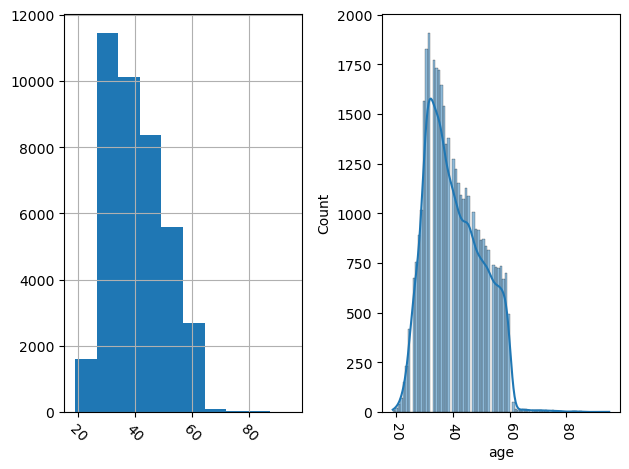


 <<< -------------------------------------------------- >>> 

balance :


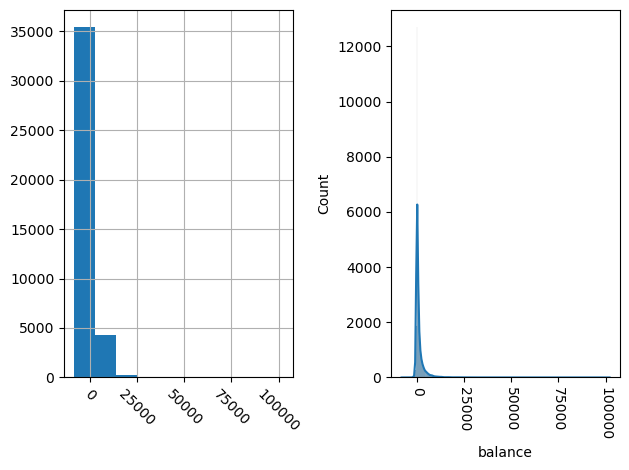


 <<< -------------------------------------------------- >>> 

day :


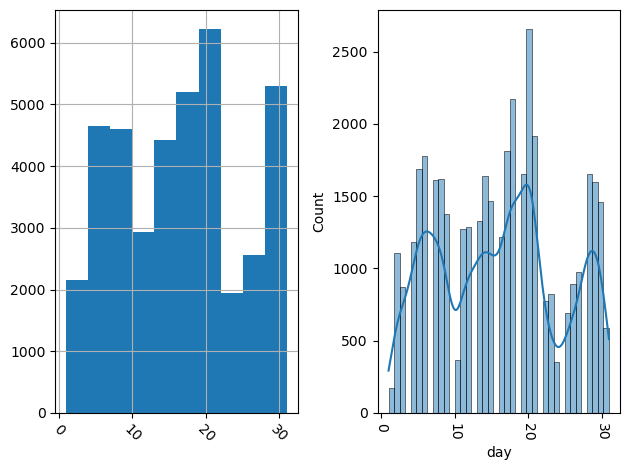


 <<< -------------------------------------------------- >>> 

duration :


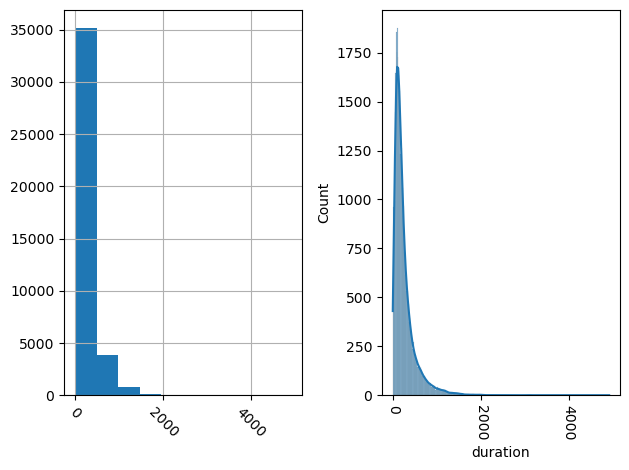


 <<< -------------------------------------------------- >>> 

campaign :


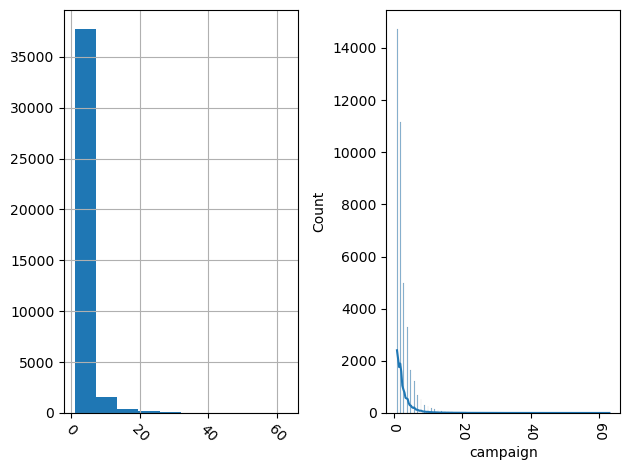


 <<< -------------------------------------------------- >>> 



In [8]:
# Histogram and KDE for numeric features
num_features = df.select_dtypes("int").columns

for feature in num_features:
    print(bold(feature), ":")
    plot_feat_num(df, feature)
    barrier()

#### Duration

In [9]:
df["duration"].describe()

count    40000.000000
mean       254.824300
std        259.366498
min          0.000000
25%        100.000000
50%        175.000000
75%        313.000000
max       4918.000000
Name: duration, dtype: float64

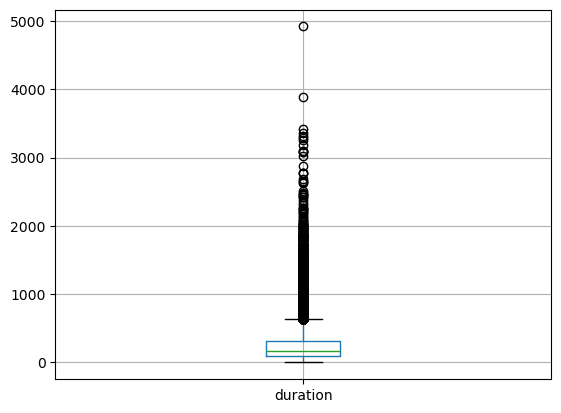

In [10]:
df[["duration"]].boxplot()
plt.show()

**NOTE:**
- A significant number of data points are greater than the 75th percentile of this feature.

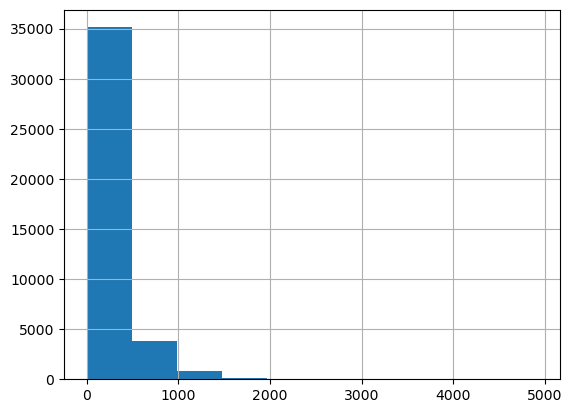

In [11]:
df["duration"].hist(bins=10)
plt.show()

#### Campaign

In [12]:
df["campaign"].describe()

count    40000.000000
mean         2.882175
std          3.239051
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

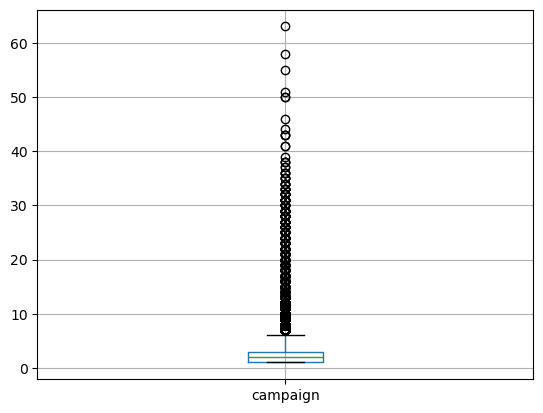

In [13]:
df[["campaign"]].boxplot()
plt.show()

**NOTE:**
- A significant number of data points are greater than the 75th percentile of this feature.

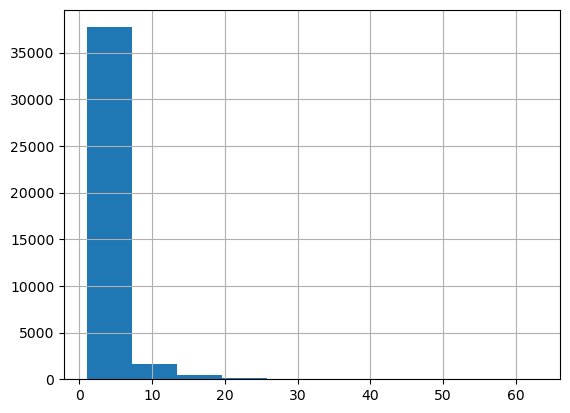

In [14]:
df["campaign"].hist(bins=10)
plt.show()

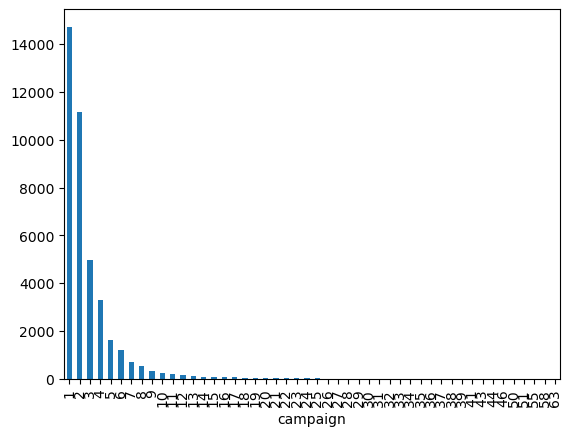

In [15]:
# Number of times individuals were contacted during campaign
df["campaign"].value_counts().sort_index().plot.bar()
plt.show()

#### Age

In [16]:
df["age"].describe()

count    40000.000000
mean        40.544600
std          9.641776
min         19.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

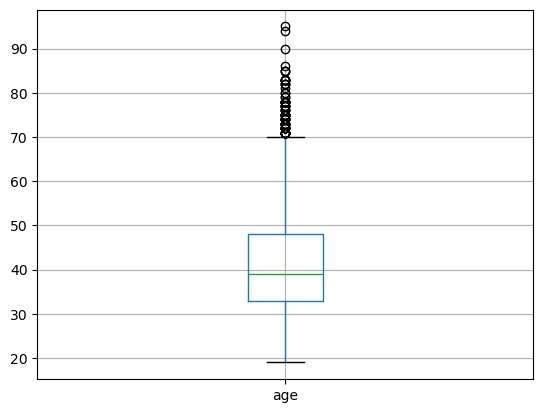

In [17]:
df[["age"]].boxplot()
plt.show()

**NOTE:**
- A significant number of data points are greater than the 75th percentile of this feature.

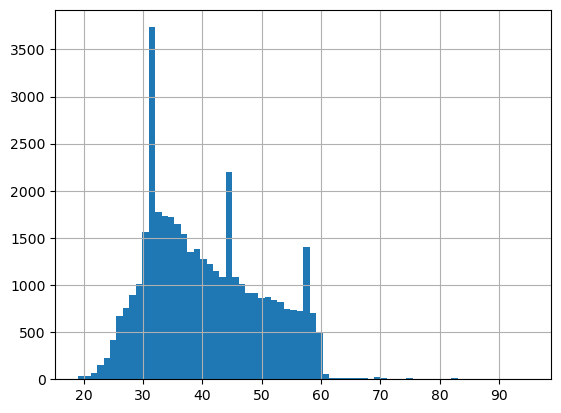

In [18]:
df["age"].hist(bins=len(df["age"].unique()))
plt.show()

#### Balance

In [19]:
df["balance"].describe()

count     40000.000000
mean       1274.277550
std        2903.769716
min       -8019.000000
25%          54.000000
50%         407.000000
75%        1319.000000
max      102127.000000
Name: balance, dtype: float64

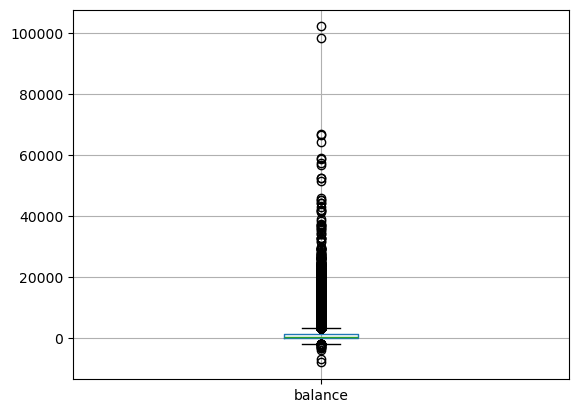

In [20]:
df[["balance"]].boxplot()
plt.show()

**NOTE:**
- A significant number of data points are both less than the 25th percentile and greater than the 75th percentile of this feature.

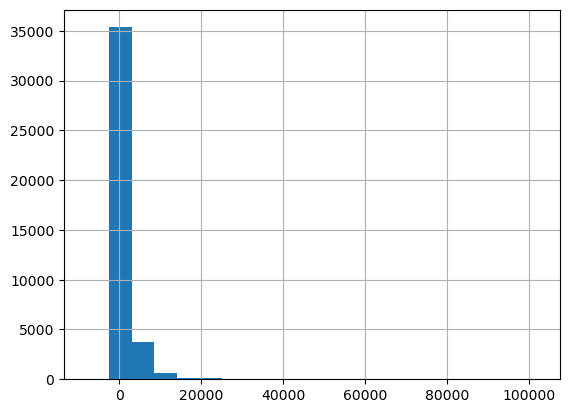

In [21]:
df["balance"].hist(bins=20)
plt.show()

### Categorical features

#### Day

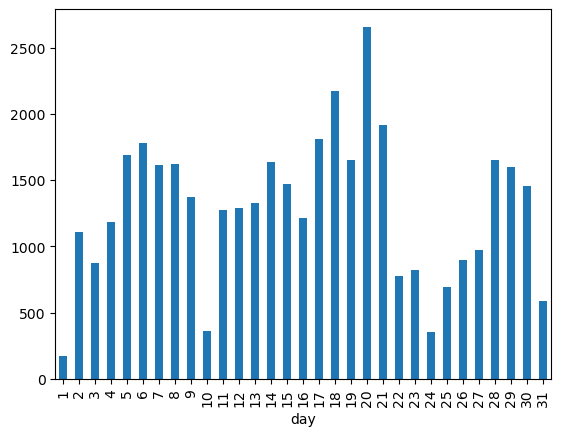

In [22]:
df["day"].value_counts().sort_index().plot.bar()
plt.show()

#### Month

In [23]:
df["month"].value_counts()

month
may    13532
jul     6380
aug     5215
jun     4734
nov     3598
apr     2718
feb     2296
jan     1176
mar      258
oct       80
dec       13
Name: count, dtype: int64

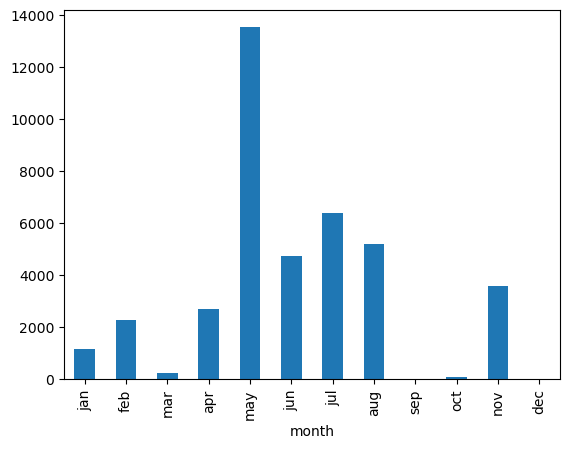

In [24]:
# Reindex months to chronological order
months = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
df["month"].value_counts().reindex(months).plot.bar()
plt.show()

#### Y or Subscription

In [25]:
df.y.value_counts()

y
no     37104
yes     2896
Name: count, dtype: int64

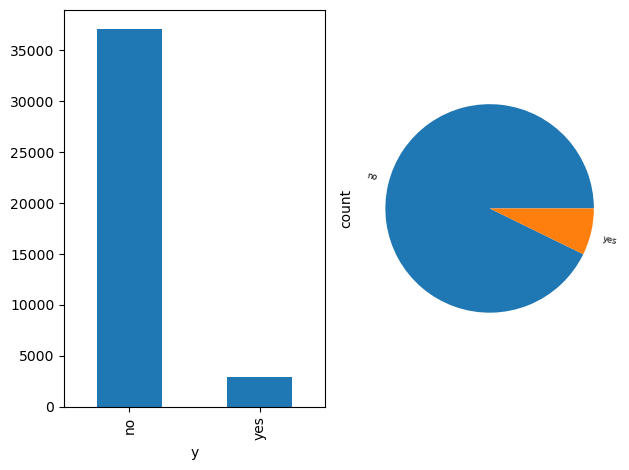

In [26]:
plot_feat_cat(df, "y")

#### Others

job :


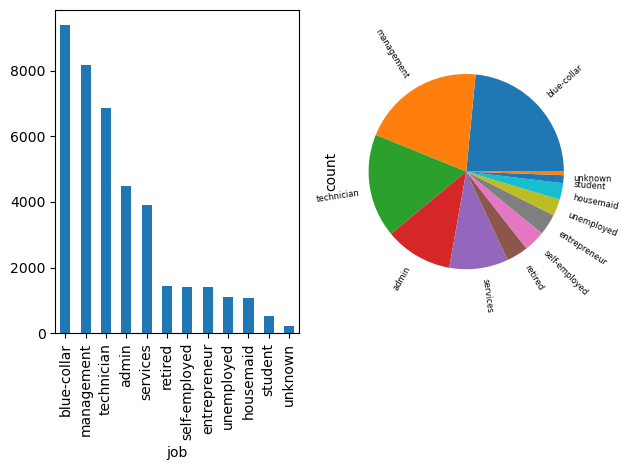


 <<< -------------------------------------------------- >>> 

marital :


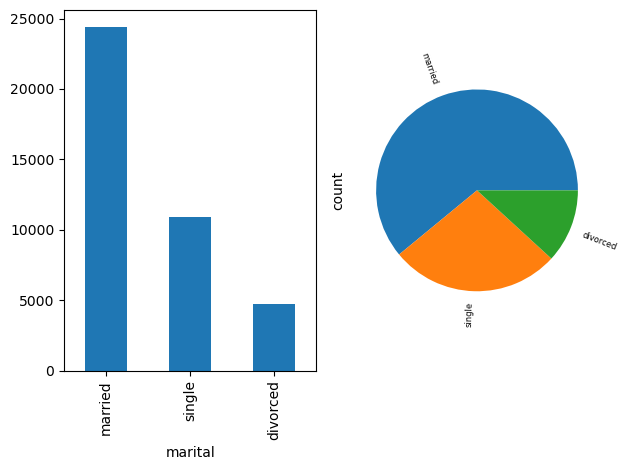


 <<< -------------------------------------------------- >>> 

education :


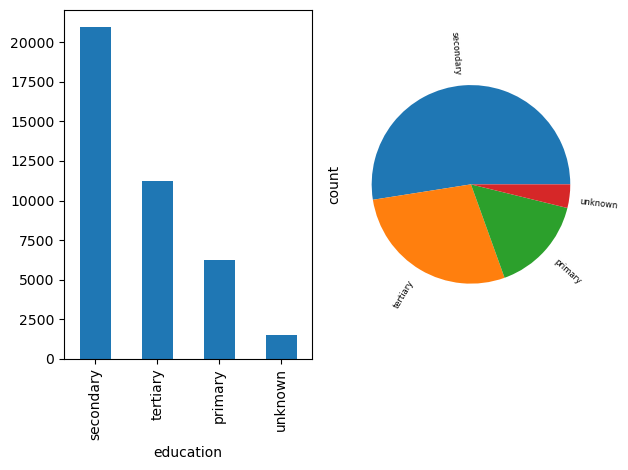


 <<< -------------------------------------------------- >>> 

default :


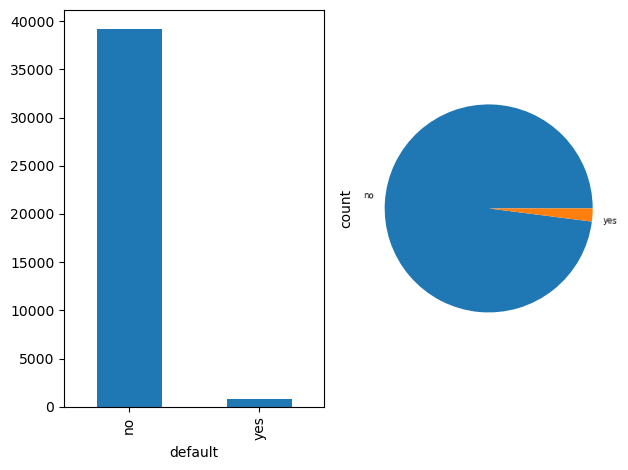


 <<< -------------------------------------------------- >>> 

housing :


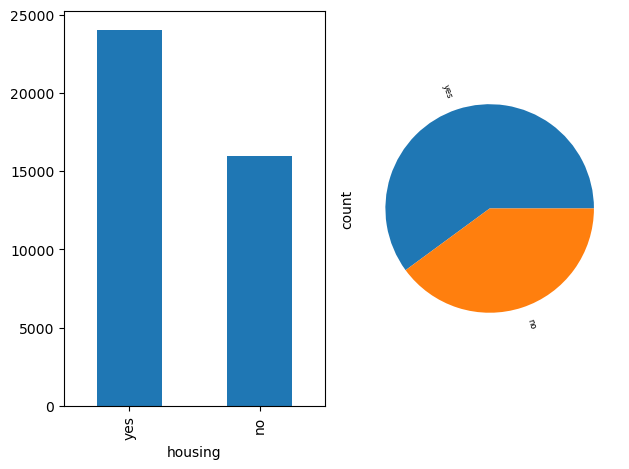


 <<< -------------------------------------------------- >>> 

loan :


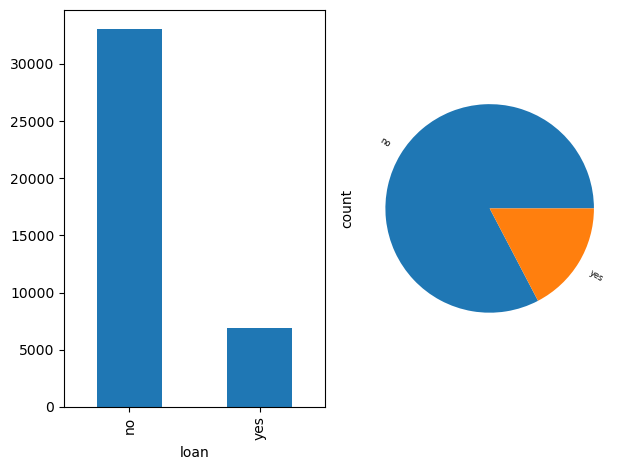


 <<< -------------------------------------------------- >>> 

contact :


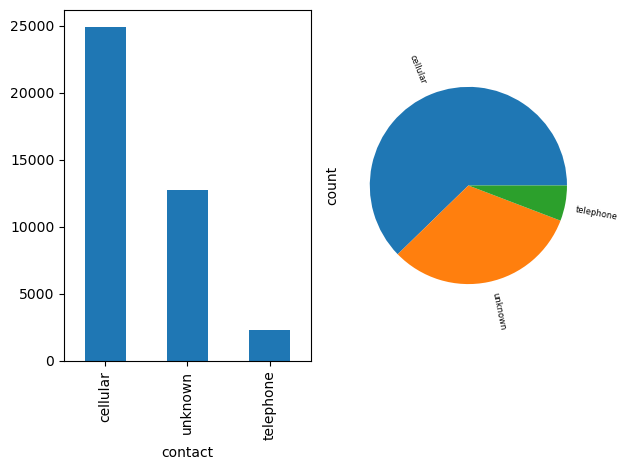


 <<< -------------------------------------------------- >>> 



In [27]:
# All categorical features except day, month or y
cat_features = [feature for feature in df.select_dtypes("object").columns if feature not in ["month", "y"]]

for feature in cat_features:
    print(bold(feature), ":")
    plot_feat_cat(df, feature)
    barrier()

## Preprocessing
### Null values

In [28]:
# Missing values
print(df.isnull().sum())
barrier()
print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

 <<< -------------------------------------------------- >>> 

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64


**NOTE:**
- There are no missing values (null or nan) in our dataset.

In [29]:
# Print unique values in each column/feature
print_uniques(df)

age ------> [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81]
job ------> ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital ------> ['married' 'single' 'divorced']
education ------> ['tertiary' 'secondary' 'unknown' 'primary']
default ------> ['no' 'yes']
balance ------> [  2143     29      2 ...   7222   3402 102127]
housing ------> ['yes' 'no']
loan ------> ['no' 'yes']
contact ------> ['unknown' 'cellular' 'telephone']
day ------> [ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
month ------> ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr']
duration ------> [ 261  151   76 ... 1880 1460 2219]
campaign ------> [ 1  2  3  5  4  6  7  8  9 10 11 12 13 19 

**NOTE:**
- There are "unknown" values in the **job**, **education** and **contact** non-integer features.
- These are effectively missing values that aren't marked null or nan.

In [30]:
# Replace unknown values with nan
df.replace("unknown", np.nan, inplace=True)

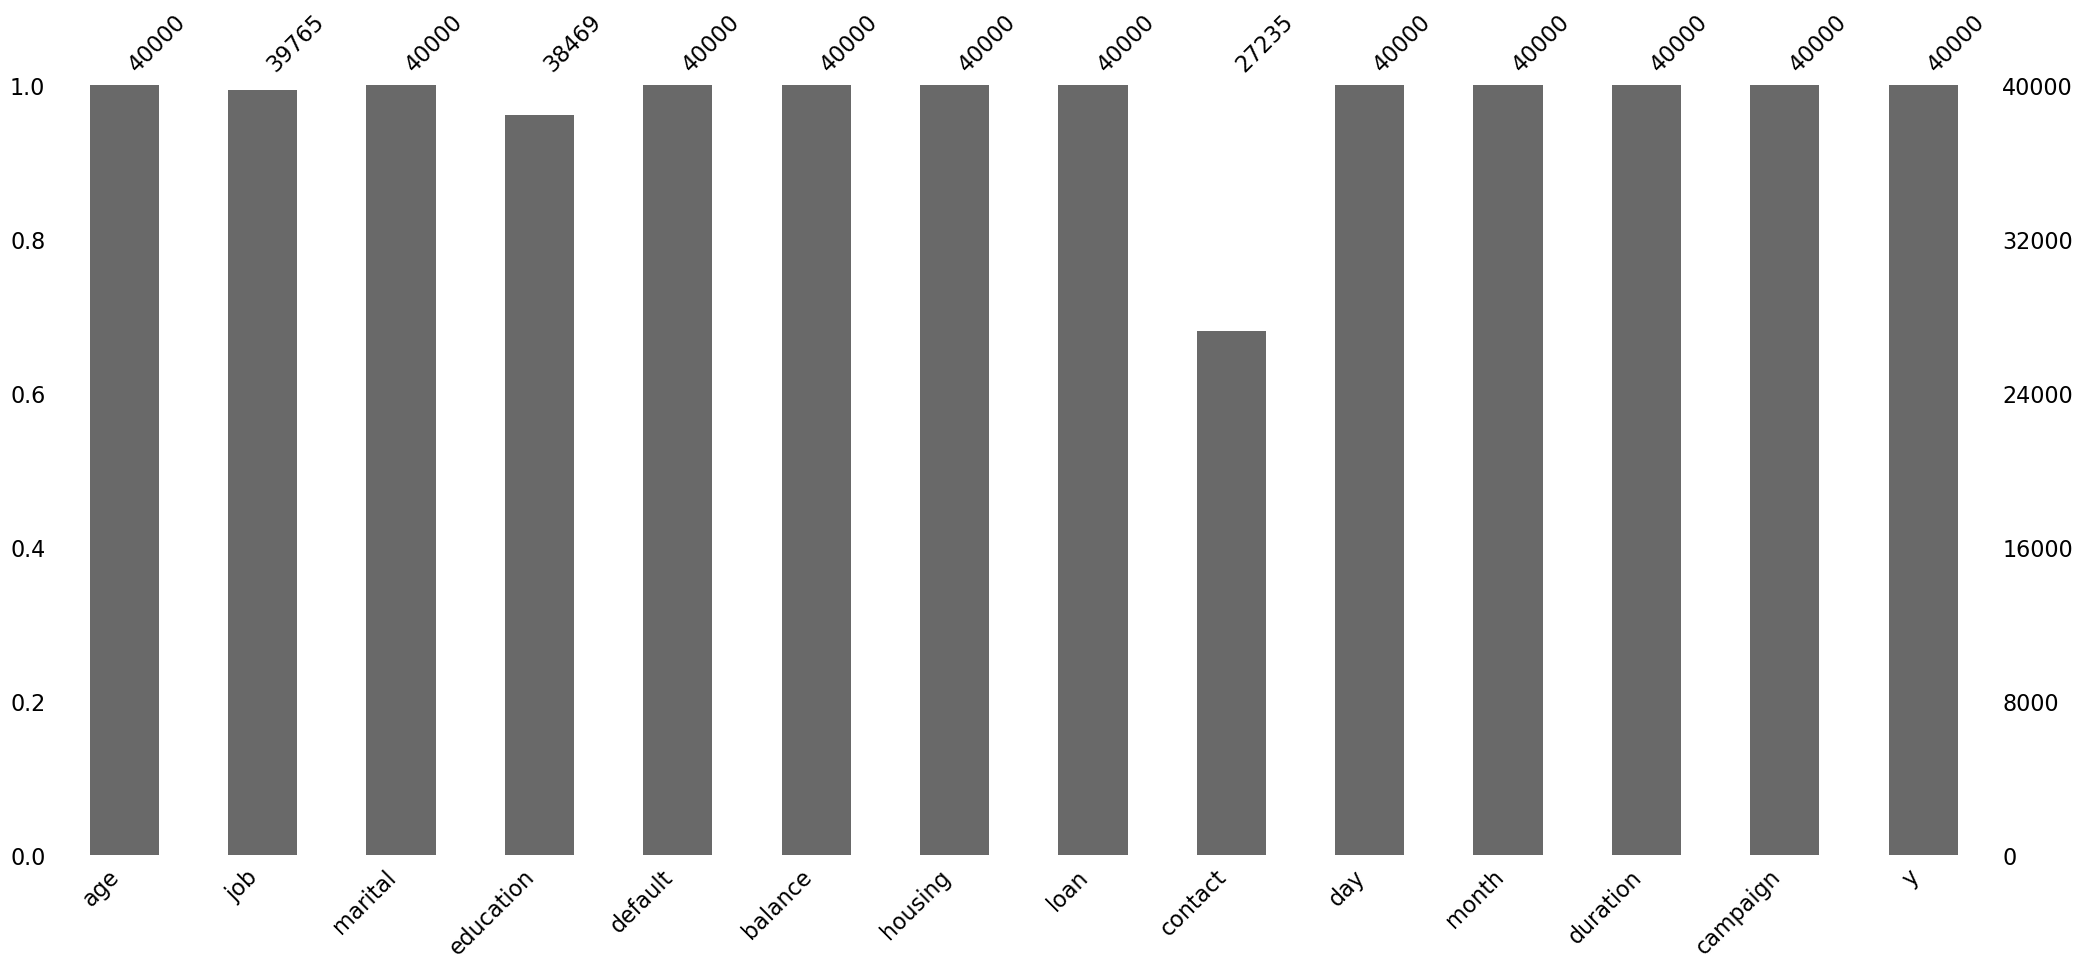

In [31]:
# Graphical depiction of missing values
msno.bar(df)
plt.show()

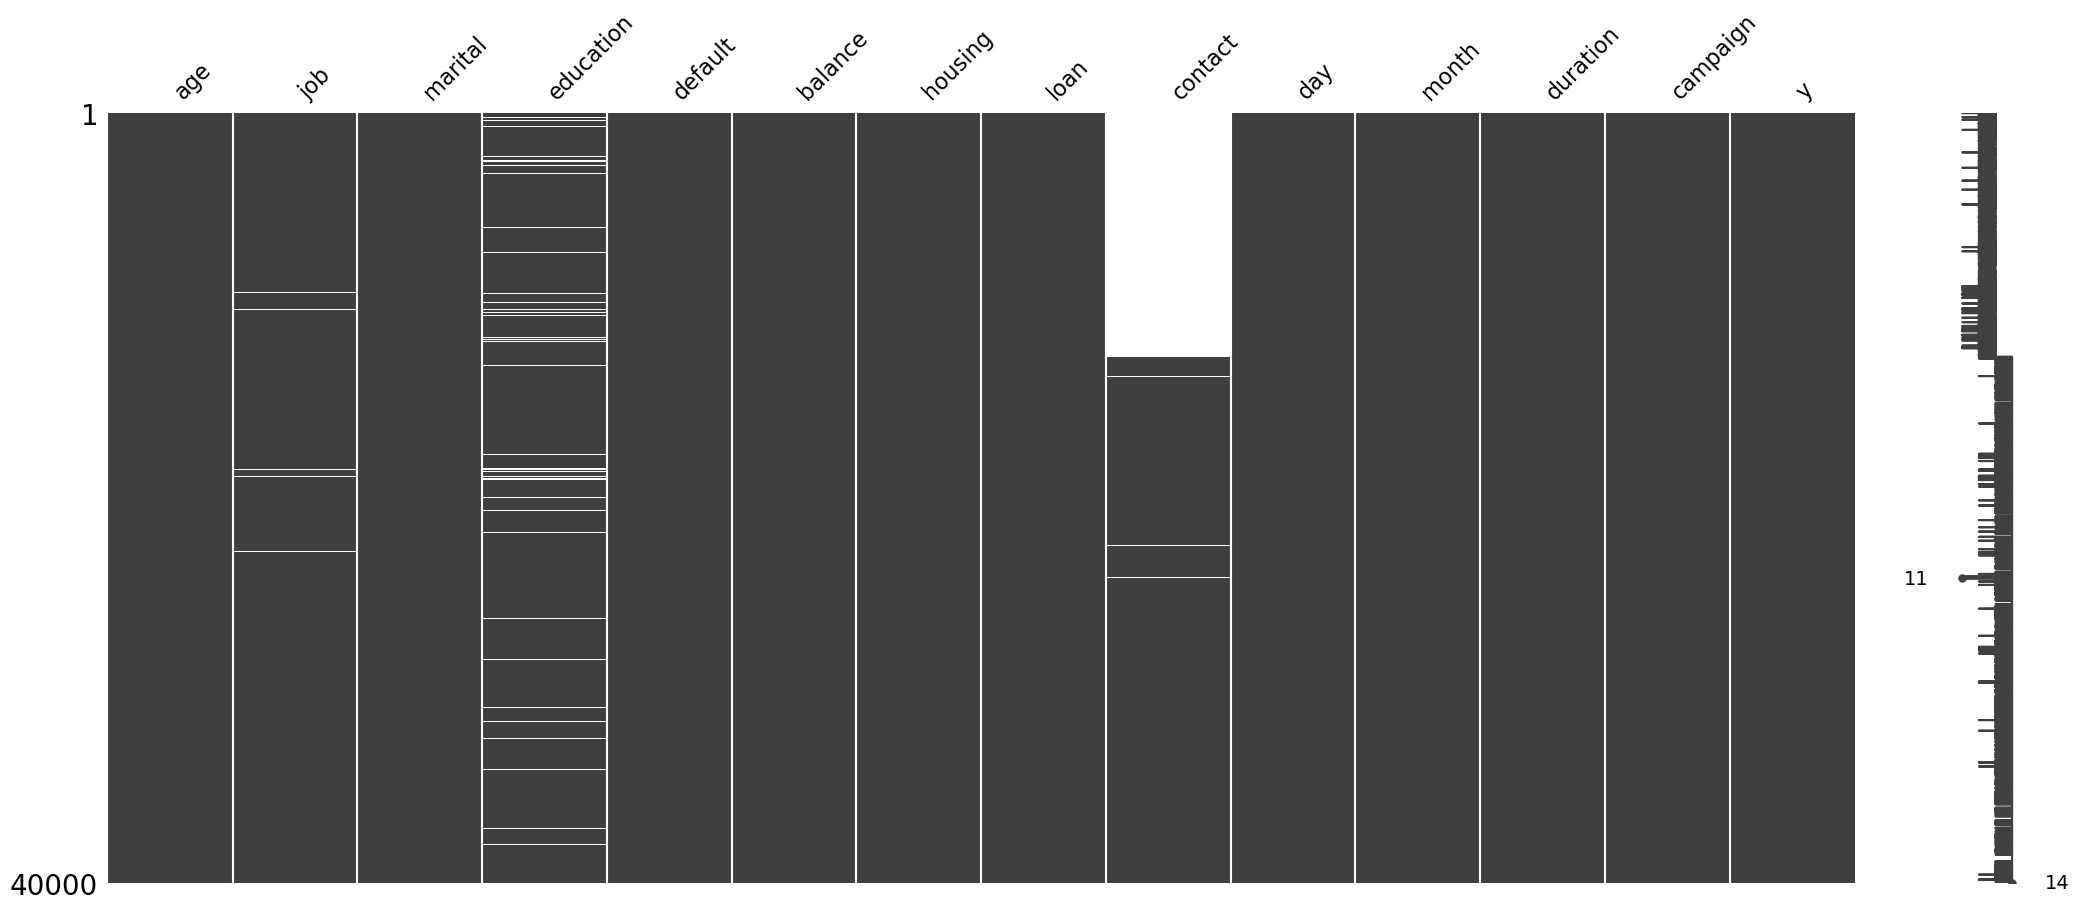

In [32]:
# Graphical depiction of missing values
msno.matrix(df)
plt.show()

#### Random imputation

In [33]:
df["job"] = na_random_fill(df["job"])
df["education"] = na_random_fill(df["education"])
df["contact"] = na_random_fill(df["contact"])

# Missing values check
print(df.isnull().sum())
barrier()
print(df.isna().sum())


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

 <<< -------------------------------------------------- >>> 

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64


**NOTE:**
- Missing/null values have been removed from the dataset.

#### Label encoding

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [35]:
# Object dtypes
display(df.select_dtypes("object").columns)

# Int dtypes
display(df.select_dtypes("int").columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'y'],
      dtype='object')

Index(['age', 'balance', 'day', 'duration', 'campaign'], dtype='object')

In [36]:
# Label encoding for object dtypes
features = df.select_dtypes("object").columns
df_enc = df.copy()
df_enc[features]=df_enc[features].apply(lambda ser:pd.Series(LabelEncoder().fit_transform(ser),index=ser.index))

display(df.head())
barrier()
display(df_enc.head())
barrier()
display(df.info())
barrier()
display(df_enc.info())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,no
3,47,blue-collar,married,primary,no,1506,yes,no,cellular,5,may,92,1,no
4,33,admin,single,tertiary,no,1,no,no,cellular,5,may,198,1,no



 <<< -------------------------------------------------- >>> 



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,4,1,2,0,2143,1,0,0,5,8,261,1,0
1,44,9,2,1,0,29,1,0,0,5,8,151,1,0
2,33,2,1,1,0,2,1,1,0,5,8,76,1,0
3,47,1,1,0,0,1506,1,0,0,5,8,92,1,0
4,33,0,2,2,0,1,0,0,0,5,8,198,1,0



 <<< -------------------------------------------------- >>> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


None


 <<< -------------------------------------------------- >>> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  int64
 2   marital    40000 non-null  int64
 3   education  40000 non-null  int64
 4   default    40000 non-null  int64
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  int64
 7   loan       40000 non-null  int64
 8   contact    40000 non-null  int64
 9   day        40000 non-null  int64
 10  month      40000 non-null  int64
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  int64
dtypes: int64(14)
memory usage: 4.3 MB


None

### Balancing the target feature

In [37]:
df.y.value_counts()

y
no     37104
yes     2896
Name: count, dtype: int64

**NOTE:**
- There are 37104 `no` values and only 2896 `yes` values.
- We will under-sample the data so as not to skew the prediction in favor of one potential outcome.
    - We will do this by creating a sub dataset with an equal number of "yes" and "no" values.

In [38]:
# Stratified train/test split is performed BEFORE under-sampling so the test
# set keeps the natural class distribution. Only the training fold is
# balanced; this avoids the data leakage caused by under-sampling the full
# dataset prior to the split.
RANDOM_STATE = 42

df_train_enc, df_test_enc = train_test_split(
    df_enc,
    test_size=0.30,
    stratify=df_enc["y"],
    random_state=RANDOM_STATE,
)

ones = df_train_enc[df_train_enc["y"] == 1]
zeros = df_train_enc[df_train_enc["y"] == 0].sample(n=len(ones), random_state=RANDOM_STATE)
df_train_balanced = (
    pd.concat([ones, zeros])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# Backwards-compatible alias used by the descriptive cells below
df_enc_balanced = df_train_balanced

print_bold("Training set (balanced) class counts:")
print(df_train_balanced["y"].value_counts())
barrier()
print_bold("Test set (natural distribution) class counts:")
print(df_test_enc["y"].value_counts())
df_train_balanced


Training set (balanced) class counts:
y
1    2027
0    2027
Name: count, dtype: int64

 <<< -------------------------------------------------- >>> 

Test set (natural distribution) class counts:
y
0    11131
1      869
Name: count, dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,55,3,1,0,0,2152,0,0,0,19,6,922,2,1
1,28,1,1,1,0,2788,1,0,0,6,6,369,2,1
2,42,1,2,0,0,1628,1,0,0,25,5,590,8,1
3,47,1,2,0,0,355,1,0,0,14,8,144,3,0
4,34,1,1,1,0,1089,1,0,0,13,8,394,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4049,32,7,1,1,0,983,1,0,0,20,9,500,2,1
4050,39,9,1,1,0,251,1,0,0,17,5,342,2,1
4051,48,1,1,1,0,863,1,0,1,4,8,412,5,1
4052,35,6,1,0,0,712,1,0,0,15,8,192,1,0


## Modeling full

#### Methodology

**NOTE:**
- Since we are targeting customers, we may make the intelligent assumption that KNN will be a good model since it is very good at classifying customer behaviors and customer demographics.
- Additionally, tree based models are very good when working with a combination of categorical/numeric data with minimal feature engineering.
- Similarly, boosting models are robust as they utilize an ensemble of multiple estimators as well as random feature sampling.
- This will be investigated in the sections below.

**NOTE:**
- Model hyperparameters are tuned for best performance and to mitigate overfitting. This is done using cross validation.
- Hyperparameter tuning is expensive; both computationally and timewise.

#### One hot encoding

In [39]:
df_enc_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4054 entries, 0 to 4053
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4054 non-null   int64
 1   job        4054 non-null   int64
 2   marital    4054 non-null   int64
 3   education  4054 non-null   int64
 4   default    4054 non-null   int64
 5   balance    4054 non-null   int64
 6   housing    4054 non-null   int64
 7   loan       4054 non-null   int64
 8   contact    4054 non-null   int64
 9   day        4054 non-null   int64
 10  month      4054 non-null   int64
 11  duration   4054 non-null   int64
 12  campaign   4054 non-null   int64
 13  y          4054 non-null   int64
dtypes: int64(14)
memory usage: 443.5 KB


In [40]:
print_uniques(df_enc_balanced)

age ------> [55 28 42 47 34 38 36 33 44 29 43 26 54 46 50 61 25 30 59 74 39 53 31 48
 41 45 32 35 49 37 40 27 52 95 57 56 51 62 58 73 24 23 60 65 71 69 77 21
 75 76 64 70 19 83 66 68 22 63 20 78 67 72 85 90]
job ------> [ 3  1  4  7  9  6 10  0  2  5  8]
marital ------> [1 2 0]
education ------> [0 1 2]
default ------> [0 1]
balance ------> [ 2152  2788  1628 ... -1944  2754  3655]
housing ------> [0 1]
loan ------> [0 1]
contact ------> [0 1]
day ------> [19  6 25 14 13 15 18  7 21 28  2  3 16 12 30 17 20  9 31 22 29 26  4  1
  5  8 24 27 23 11 10]
month ------> [ 6  5  8  0  9  3  7  1  4 10  2]
duration ------> [ 922  369  590 ... 1107 1231 2330]
campaign ------> [ 2  8  3  5  1  9  4 11  7 17 10  6 22 15 24 14 19 12 16 20 28 13 31 44
 32 39 25]
y ------> [1 0]


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [42]:
# One-hot encode the training fold, then align test columns to match.
oh_cols = ["job", "marital", "education", "month"]
df_train_oh = pd.get_dummies(df_train_balanced, columns=oh_cols, drop_first=True)
df_test_oh = pd.get_dummies(df_test_enc, columns=oh_cols, drop_first=True)
df_test_oh = df_test_oh.reindex(columns=df_train_oh.columns, fill_value=0)

# Backwards-compatible alias
df_enc_oh = df_train_oh
df_train_oh.head()


,age,default,balance,housing,loan,contact,day,duration,campaign,y,...,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10
0,55,0,2152,0,0,0,19,922,2,1,...,False,False,False,False,False,True,False,False,False,False
1,28,0,2788,1,0,0,6,369,2,1,...,False,False,False,False,False,True,False,False,False,False
2,42,0,1628,1,0,0,25,590,8,1,...,False,False,False,False,True,False,False,False,False,False
3,47,0,355,1,0,0,14,144,3,0,...,False,False,False,False,False,False,False,True,False,False
4,34,0,1089,1,0,0,13,394,3,1,...,False,False,False,False,False,False,False,True,False,False


In [43]:
df_enc_oh.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'contact', 'day',
       'duration', 'campaign', 'y', 'job_1', 'job_2', 'job_3', 'job_4',
       'job_5', 'job_6', 'job_7', 'job_8', 'job_9', 'job_10', 'marital_1',
       'marital_2', 'education_1', 'education_2', 'month_1', 'month_2',
       'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
       'month_9', 'month_10'],
      dtype='object')

**NOTE:**
- We dropped the first columns to prevent issues with multi-collinearity.

#### Train and test split

In [44]:
X_train = df_train_oh.drop("y", axis=1)
y_train = df_train_oh["y"]
X_test = df_test_oh.drop("y", axis=1)
y_test = df_test_oh["y"]

print_bold("X_train.shape, y_train.shape, X_test.shape, y_test.shape:")
display(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print_bold("y_train.sum(), y_test.sum():")
display(y_train.sum(), y_test.sum())


X_train.shape, y_train.shape, X_test.shape, y_test.shape:


(4054, 33)

(4054,)

(12000, 33)

(12000,)

y_train.sum(), y_test.sum():


np.int64(2027)

np.int64(869)

#### Lazypredict

In [45]:
# Lazy preliminary assessment of multiple models
clf = LazyClassifier(verbose=-1, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models)

  0%|          | 0/33 [00:00<?, ?it/s]

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
LGBMClassifier                 0.865167           0.882231  0.939101   
XGBClassifier                  0.866667           0.876144  0.934095   
CatBoostClassifier             0.866167           0.875344  0.939735   
RandomForestClassifier         0.851667           0.862754  0.923953   
BaggingClassifier              0.864167           0.854639  0.913790   
SVC                            0.853000           0.853925  0.923312   
LogisticRegression             0.859417           0.853670  0.925108   
CalibratedClassifierCV         0.859583           0.852169  0.925608   
NuSVC                          0.857417           0.852062  0.923291   
LinearSVC                      0.861417           0.851035  0.925383   
ExtraTreesClassifier           0.843917           0.842663  0.912422   
RidgeClassifier                0.878500           0.837965  0.92

**NOTE:**
- Lazypredict provides an initial estimation of how different models may perform with the data.
- However, this assessment should be considered a rough guideline as it is made without model tuning.
- Thus, it will only serve informational purposes going forward.

#### Model evaluation functions

In [46]:
# Functions to evaluate models
def draw_roc(model):
    """ROC curve / AUC computed on the held-out test set only."""
    y_score = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "r--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - AUC (area={roc_auc:.4f})")
    plt.show()


def evaluate(model):
    """Fit, then report training/test accuracy, 5-fold CV (on TRAIN), report,
    ROC and confusion matrix."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cross_val = cross_val_score(model, X_train, y_train, cv=5).mean()
    print_bold(f"Training accuracy: {model.score(X_train, y_train)}")
    print_bold(f"Test accuracy: {accuracy_score(y_test, y_pred)}")
    print_bold(f"5-Fold Cross Validation Accuracy: {cross_val}")
    barrier()
    print_bold("Classification report:")
    print(classification_report(y_test, y_pred))
    barrier()
    draw_roc(model)
    barrier()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title("Confusion Matrix")
    plt.show()


def evaluate_no_fit(model):
    """Same as ``evaluate`` but assumes the model has already been fit."""
    y_pred = model.predict(X_test)
    cross_val = cross_val_score(model, X_train, y_train, cv=5).mean()
    print_bold(f"Training accuracy: {model.score(X_train, y_train)}")
    print_bold(f"Test accuracy: {accuracy_score(y_test, y_pred)}")
    print_bold(f"5-Fold Cross Validation Accuracy: {cross_val}")
    barrier()
    print_bold("Classification report:")
    print(classification_report(y_test, y_pred))
    barrier()
    draw_roc(model)
    barrier()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title("Confusion Matrix")
    plt.show()


def cv_std(cv):
    """Plot the std-dev of CV scores across the GridSearchCV parameter grid."""
    y_std = cv.cv_results_["std_test_score"]
    x = np.arange(1, y_std.shape[0] + 1)
    print(f"Mean of the standard deviations: {y_std.mean()}")
    print(f"Std of the standard deviations: {y_std.std()}")
    barrier()
    plt.plot(x, y_std)
    plt.title("Standard devs of CV scores")
    plt.xlabel("Param Candidates")
    plt.ylabel("Stds")
    plt.show()


### Logistic regression

Training accuracy: 0.8275777010360138
Test accuracy: 0.84725
5-Fold Cross Validation Accuracy: 0.8105566972644654

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     11131
           1       0.30      0.83      0.44       869

    accuracy                           0.85     12000
   macro avg       0.64      0.84      0.68     12000
weighted avg       0.94      0.85      0.88     12000


 <<< -------------------------------------------------- >>> 



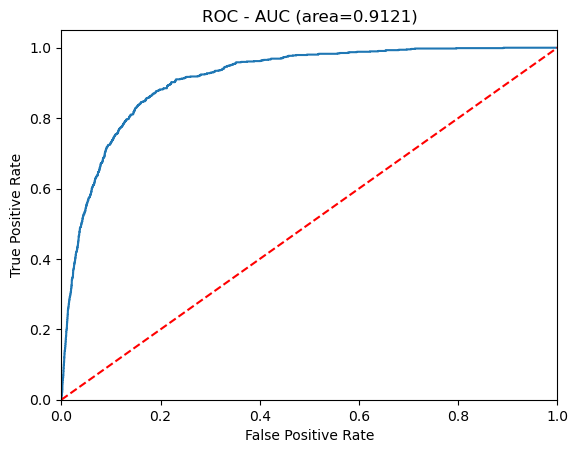


 <<< -------------------------------------------------- >>> 



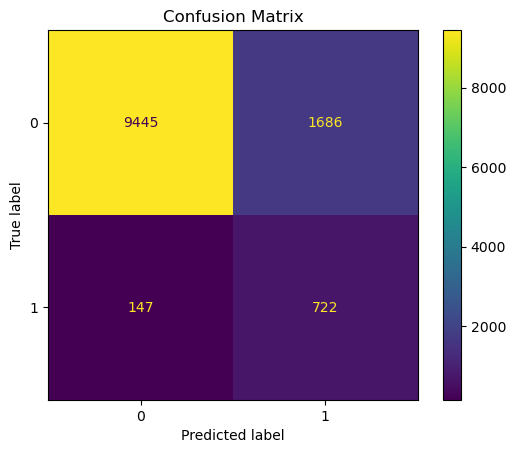

In [47]:
LR = LogisticRegression()
evaluate(LR)

In [48]:
# Save model
save_model(LR, "LR")

Model: LR.pkl saved to models/.


### Gaussian naive bayes

Training accuracy: 0.7671435619141589
Test accuracy: 0.85625
5-Fold Cross Validation Accuracy: 0.758758125161742

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     11131
           1       0.29      0.68      0.41       869

    accuracy                           0.86     12000
   macro avg       0.63      0.77      0.66     12000
weighted avg       0.92      0.86      0.88     12000


 <<< -------------------------------------------------- >>> 



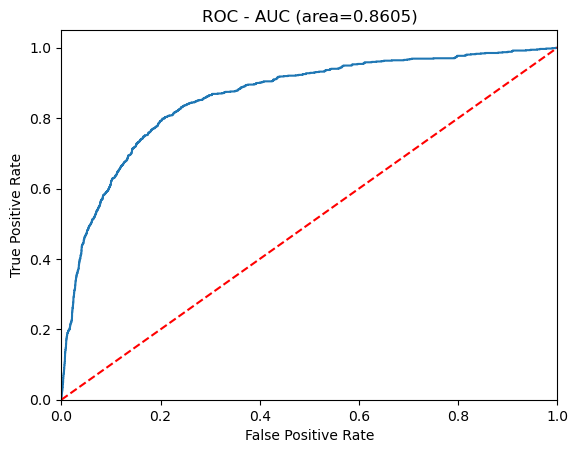


 <<< -------------------------------------------------- >>> 



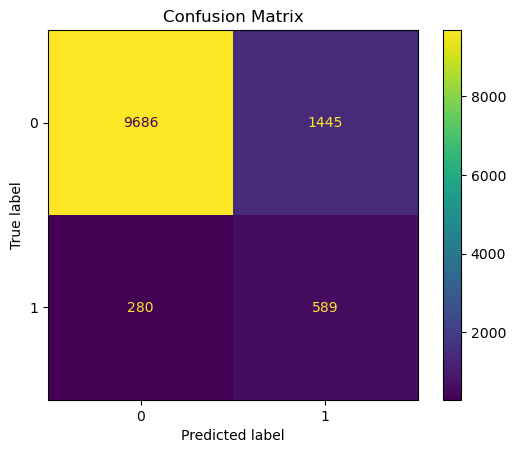

In [49]:
GNB = GaussianNB()
evaluate(GNB)

In [50]:
# Save model
save_model(GNB, "GNB")

Model: GNB.pkl saved to models/.


### K nearest neighbours

Training accuracy: 0.8374444992599901
Test accuracy: 0.7865833333333333
5-Fold Cross Validation Accuracy: 0.7710876680214945

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87     11131
           1       0.22      0.76      0.34       869

    accuracy                           0.79     12000
   macro avg       0.60      0.77      0.61     12000
weighted avg       0.92      0.79      0.83     12000


 <<< -------------------------------------------------- >>> 



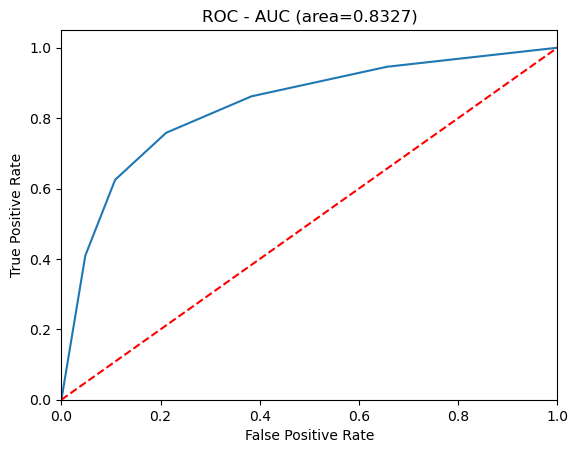


 <<< -------------------------------------------------- >>> 



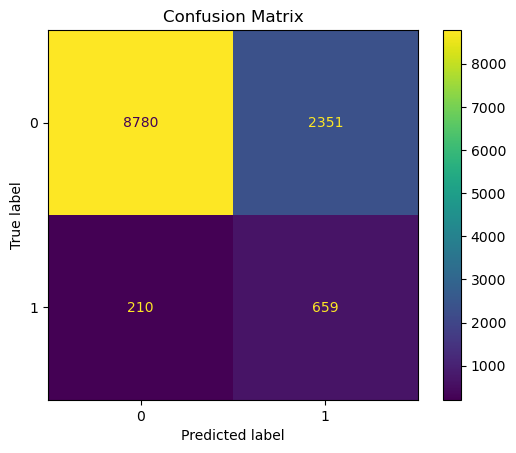

In [51]:
KNN = KNeighborsClassifier()
evaluate(KNN)

Fitting 5 folds for each of 14 candidates, totalling 70 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'n_neighbors': np.int64(11)}
Tuned model best score: 0.7853919106118037
Training accuracy: 0.8152442032560434
Test accuracy: 0.8068333333333333
5-Fold Cross Validation Accuracy: 0.7853919106118037

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     11131
           1       0.24      0.77      0.37       869

    accuracy                           0.81     12000
   macro avg       0.61      0.79      0.63     12000
weighted avg       0.93      0.81      0.85     12000


 <<< -------------------------------------------------- >>> 



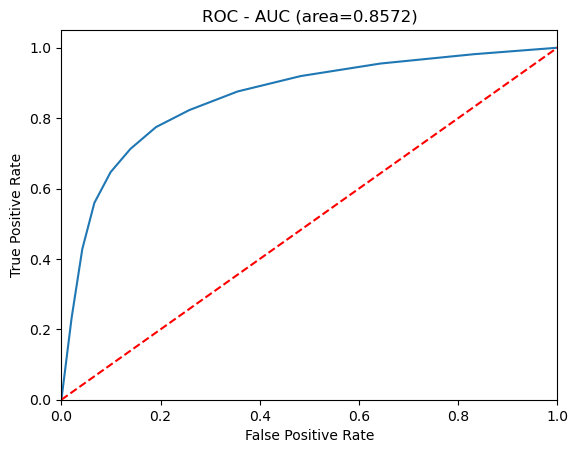


 <<< -------------------------------------------------- >>> 



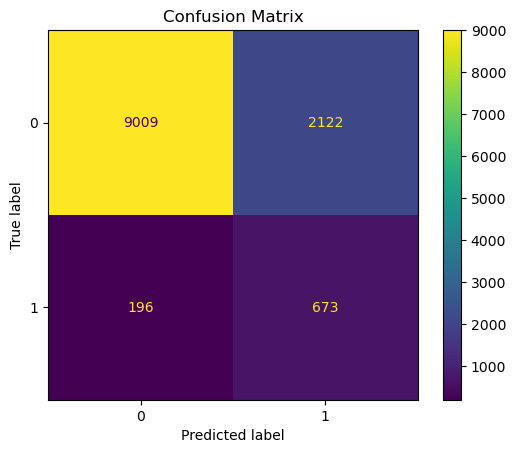

In [52]:
KNN = KNeighborsClassifier()

param_grid = {"n_neighbors": np.arange(1, 15)}

model_cv = GridSearchCV(KNN, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.8152442032560434
Test accuracy: 0.8068333333333333
5-Fold Cross Validation Accuracy: 0.7853919106118037

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     11131
           1       0.24      0.77      0.37       869

    accuracy                           0.81     12000
   macro avg       0.61      0.79      0.63     12000
weighted avg       0.93      0.81      0.85     12000


 <<< -------------------------------------------------- >>> 



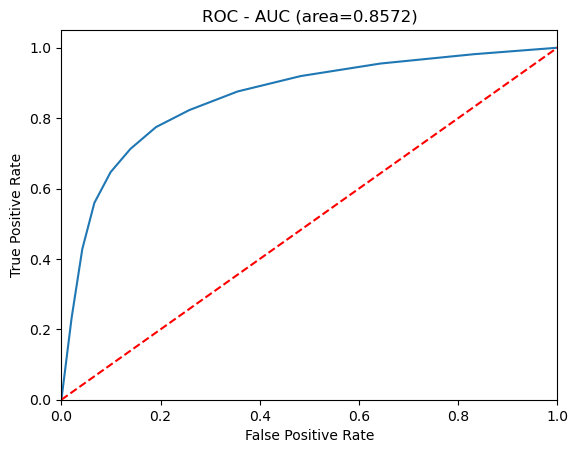


 <<< -------------------------------------------------- >>> 



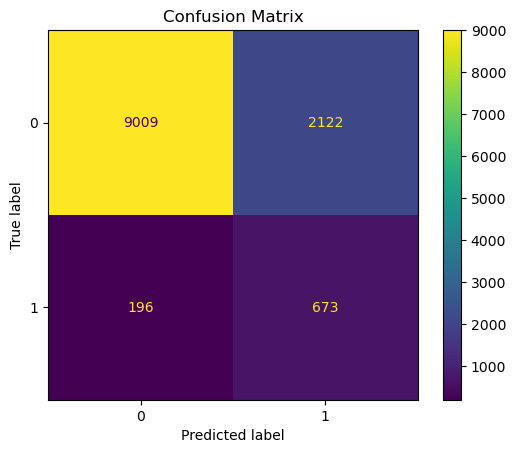

In [53]:
KNN = KNeighborsClassifier().set_params(**model_cv.best_params_)
evaluate(KNN)

### Decision tree

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'max_depth': 9, 'min_samples_split': 8}
Tuned model best score: 0.8376846143307303
Training accuracy: 0.8926985693142575
Test accuracy: 0.83825
5-Fold Cross Validation Accuracy: 0.8339851730069568

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91     11131
           1       0.29      0.83      0.42       869

    accuracy                           0.84     12000
   macro avg       0.64      0.83      0.67     12000
weighted avg       0.93      0.84      0.87     12000


 <<< -------------------------------------------------- >>> 



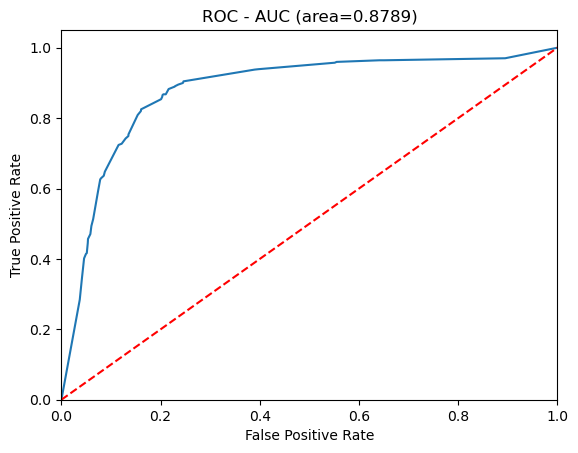


 <<< -------------------------------------------------- >>> 



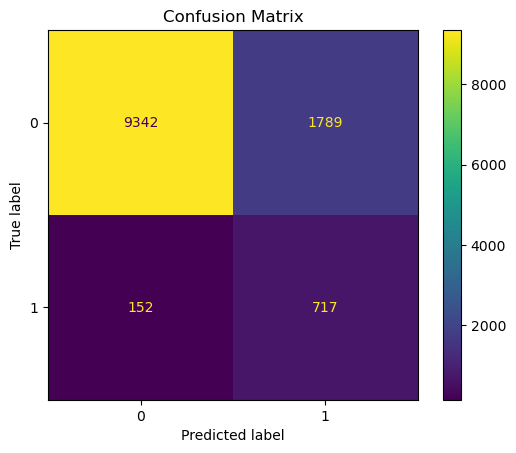

In [54]:
DTC = DecisionTreeClassifier()

param_grid = {"max_depth": range(1, 10), "min_samples_split": list(range(2, 50))}

model_cv = GridSearchCV(DTC, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.8924518993586581
Test accuracy: 0.839
5-Fold Cross Validation Accuracy: 0.835217305262517

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91     11131
           1       0.29      0.83      0.43       869

    accuracy                           0.84     12000
   macro avg       0.64      0.83      0.67     12000
weighted avg       0.93      0.84      0.87     12000


 <<< -------------------------------------------------- >>> 



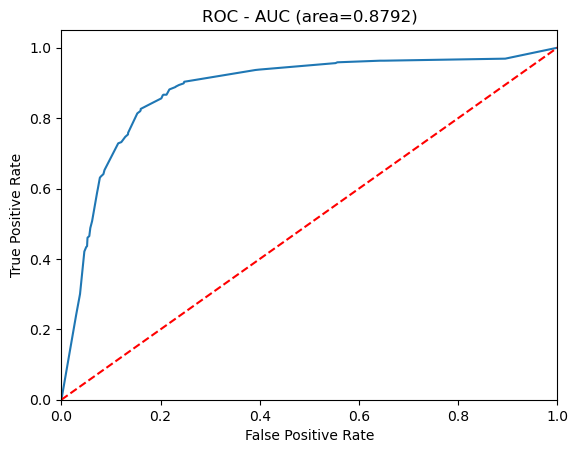


 <<< -------------------------------------------------- >>> 



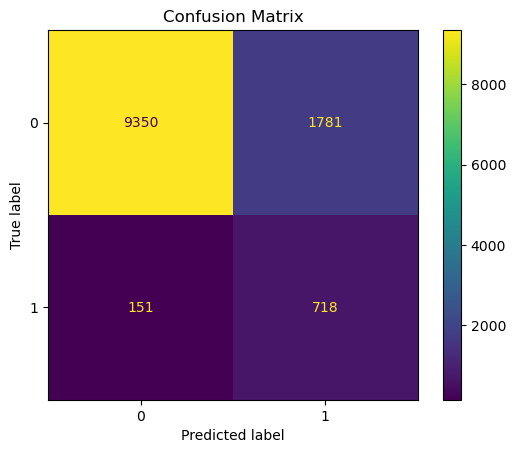

In [55]:
DTC = DecisionTreeClassifier().set_params(**model_cv.best_params_)
evaluate(DTC)

In [56]:
# Save model
save_model(DTC, "DTC")

Model: DTC.pkl saved to models/.


### Random forest

Fitting 5 folds for each of 81 candidates, totalling 405 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'max_depth': 8, 'max_features': 8, 'min_samples_split': 10, 'n_estimators': 100}
Tuned model best score: 0.8527372090545129
Training accuracy: 0.8734583127775037
Test accuracy: 0.8541666666666666
5-Fold Cross Validation Accuracy: 0.8510103362713309

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     11131
           1       0.31      0.84      0.46       869

    accuracy                           0.85     12000
   macro avg       0.65      0.85      0.69     12000
weighted avg       0.94      0.85      0.88     12000


 <<< -------------------------------------------------- >>> 



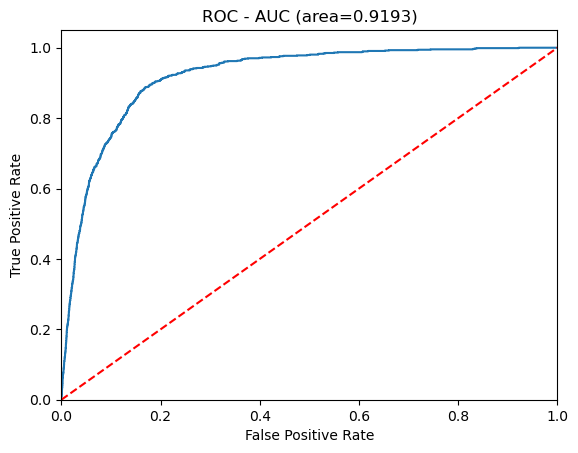


 <<< -------------------------------------------------- >>> 



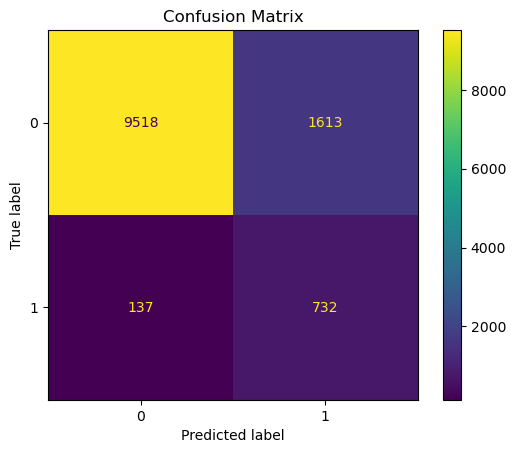

In [57]:
RF = RandomForestClassifier()

param_grid = {"max_depth":[2,5,8], "max_features":[2,5,8], "n_estimators":[10,50,100], "min_samples_split":[2,5,10]}

model_cv = GridSearchCV(RF, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.8756783423778983
Test accuracy: 0.8520833333333333
5-Fold Cross Validation Accuracy: 0.8527390357887686

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     11131
           1       0.31      0.85      0.45       869

    accuracy                           0.85     12000
   macro avg       0.65      0.85      0.68     12000
weighted avg       0.94      0.85      0.88     12000


 <<< -------------------------------------------------- >>> 



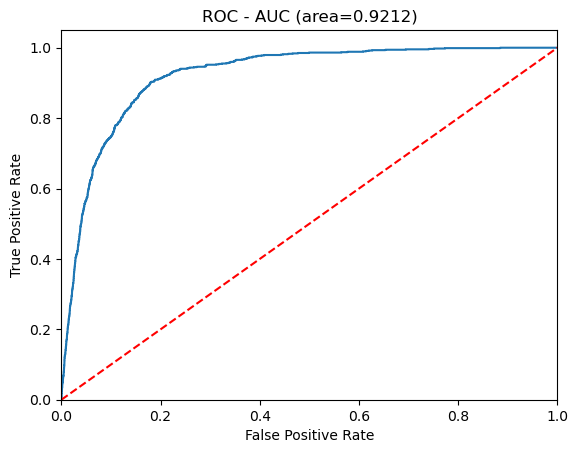


 <<< -------------------------------------------------- >>> 



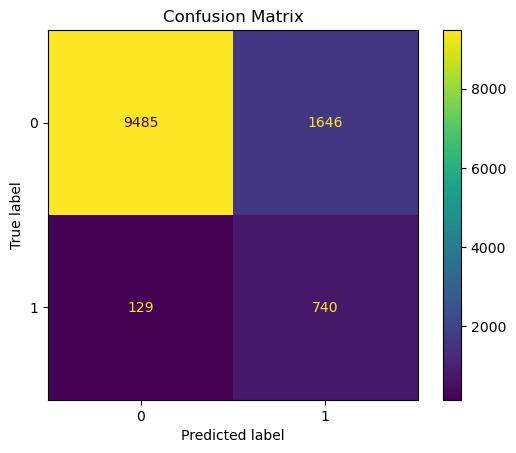

In [58]:
RF = RandomForestClassifier().set_params(**model_cv.best_params_)
evaluate(RF)

In [59]:
# Save model
save_model(RF, "RF")

Model: RF.pkl saved to models/.


### XGBoost

Training accuracy: 0.8719782930439073
Test accuracy: 0.8323333333333334
5-Fold Cross Validation Accuracy: 0.8482973314457078

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90     11131
           1       0.28      0.87      0.43       869

    accuracy                           0.83     12000
   macro avg       0.64      0.85      0.67     12000
weighted avg       0.94      0.83      0.87     12000


 <<< -------------------------------------------------- >>> 



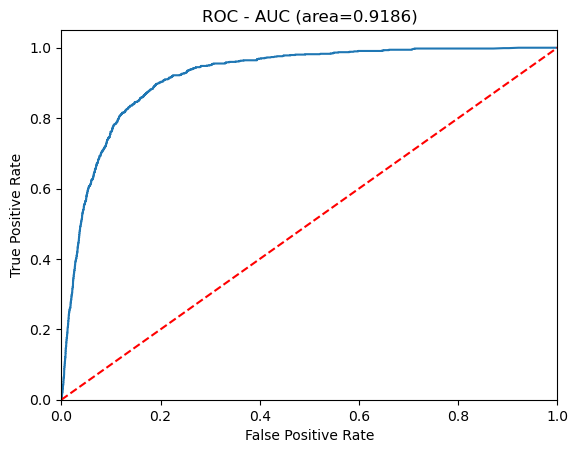


 <<< -------------------------------------------------- >>> 



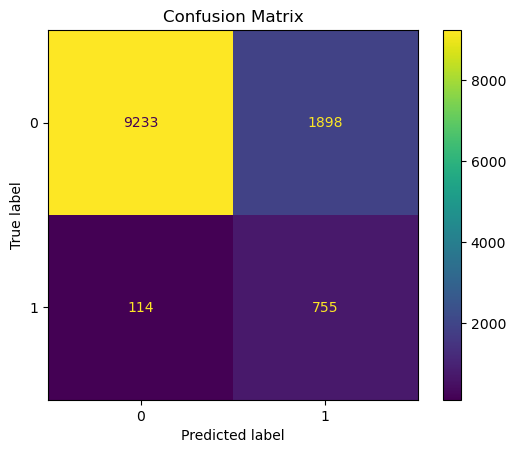

In [60]:
XGB = XGBClassifier(learning_rate=0.01, max_depth=6, min_samples_split=2, n_estimators=100, subsample=0.8)
evaluate(XGB)

In [61]:
# Save model
save_model(XGB, "XGB")

Model: XGB.pkl saved to models/.


### CatBoost

Training accuracy: 0.9398125308337445
Test accuracy: 0.8661666666666666
5-Fold Cross Validation Accuracy: 0.8717300695681296

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     11131
           1       0.34      0.89      0.49       869

    accuracy                           0.87     12000
   macro avg       0.66      0.88      0.71     12000
weighted avg       0.94      0.87      0.89     12000


 <<< -------------------------------------------------- >>> 



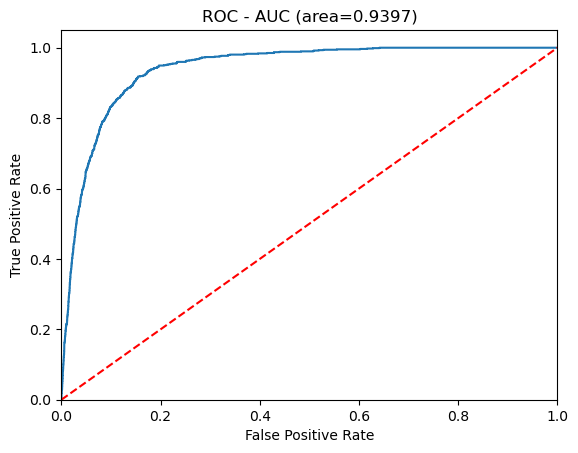


 <<< -------------------------------------------------- >>> 



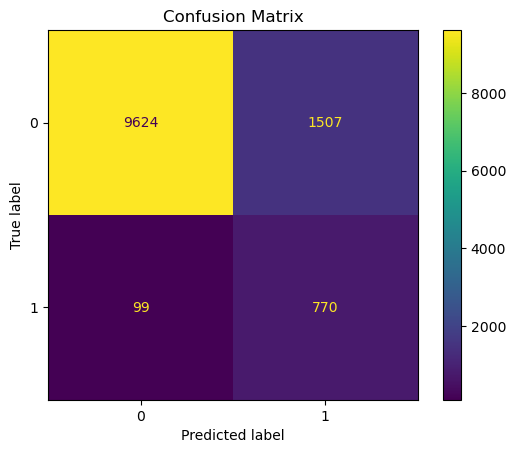

In [62]:
CAT = CatBoostClassifier(verbose=False)
# CAT = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5, verbose=False)
evaluate(CAT)

In [63]:
# Save model
save_model(CAT, "CAT")

Model: CAT.pkl saved to models/.


### LGBMClassifier

Training accuracy: 0.9555994079921065
Test accuracy: 0.86375
5-Fold Cross Validation Accuracy: 0.8687710645293876

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     11131
           1       0.34      0.90      0.49       869

    accuracy                           0.86     12000
   macro avg       0.66      0.88      0.70     12000
weighted avg       0.94      0.86      0.89     12000


 <<< -------------------------------------------------- >>> 



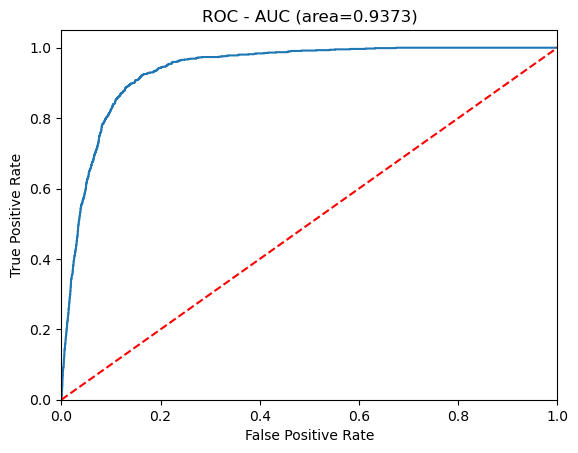


 <<< -------------------------------------------------- >>> 



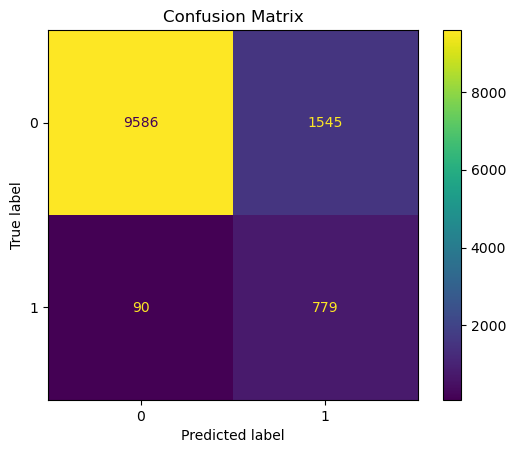

In [64]:
LGBM = LGBMClassifier(verbosity=-1)
evaluate(LGBM)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_samples': 20, 'n_estimators': 500, 'subsample': 0.6}
Tuned model best score: 0.8744421610266248
Training accuracy: 0.906265416872225
Test accuracy: 0.86475
5-Fold Cross Validation Accuracy: 0.8744421610266248

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     11131
           1       0.34      0.89      0.49       869

    accuracy                           0.86     12000
   macro avg       0.66      0.88      0.70     12000
weighted avg       0.94      0.86      0.89     12000


 <<< -------------------------------------------------- >>> 



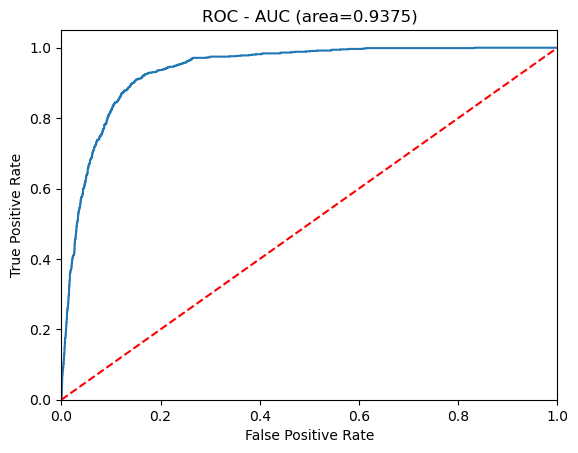


 <<< -------------------------------------------------- >>> 



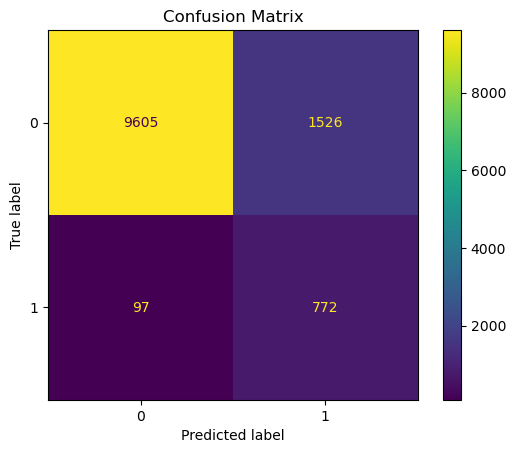

In [65]:
LGBM = LGBMClassifier(verbosity=-1)

param_grid = {"n_estimators":[100, 500], "subsample":[0.6,0.8,1.0], "max_depth":[3, 4, 5],
              "learning_rate":[0.1, 0.01, 0.05], "min_child_samples":[5, 10, 20]}

model_cv = GridSearchCV(LGBM, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.906265416872225
Test accuracy: 0.86475
5-Fold Cross Validation Accuracy: 0.8744421610266248

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     11131
           1       0.34      0.89      0.49       869

    accuracy                           0.86     12000
   macro avg       0.66      0.88      0.70     12000
weighted avg       0.94      0.86      0.89     12000


 <<< -------------------------------------------------- >>> 



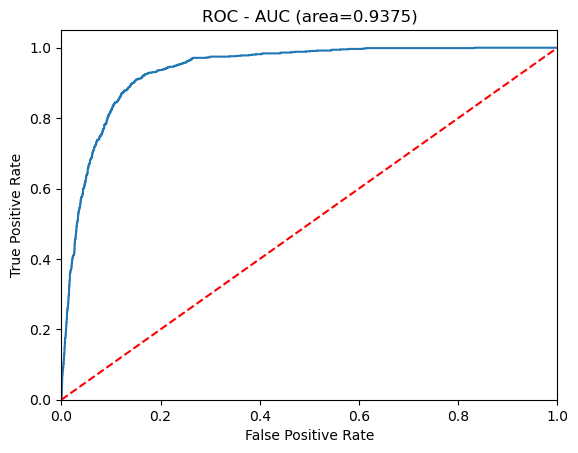


 <<< -------------------------------------------------- >>> 



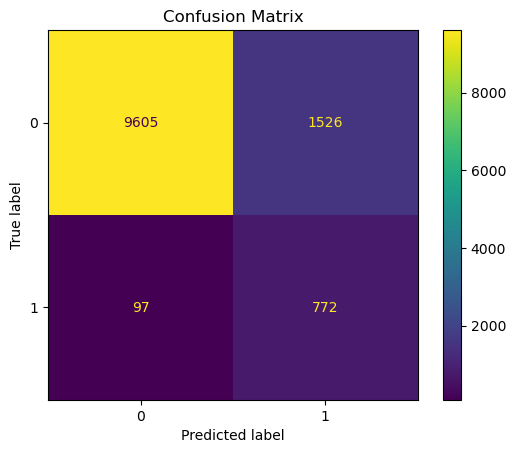

In [66]:
LGBM = LGBMClassifier(verbosity=-1).set_params(**model_cv.best_params_)
evaluate(LGBM)

In [67]:
# Save model
save_model(LGBM, "LGBM")

Model: LGBM.pkl saved to models/.


### Final model collation

In [68]:
# Load saved models
DTC_feat_imp = load_model("DTC.pkl")
RF_feat_imp = load_model("RF.pkl")
XGB_feat_imp = load_model("XGB.pkl")
CAT_feat_imp = load_model("CAT.pkl")
LGBM_feat_imp = load_model("LGBM.pkl")

In [69]:
models = [DTC_feat_imp, RF_feat_imp, XGB_feat_imp, CAT_feat_imp, LGBM_feat_imp]

for model in models:
    names = model.__class__.__name__
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print_bold(names + ":" )
    print(f"Test accuracy: {acc}")
    barrier()

DecisionTreeClassifier:
Test accuracy: 0.839

 <<< -------------------------------------------------- >>> 

RandomForestClassifier:
Test accuracy: 0.8520833333333333

 <<< -------------------------------------------------- >>> 

XGBClassifier:
Test accuracy: 0.8323333333333334

 <<< -------------------------------------------------- >>> 

CatBoostClassifier:
Test accuracy: 0.8661666666666666

 <<< -------------------------------------------------- >>> 

LGBMClassifier:
Test accuracy: 0.86475

 <<< -------------------------------------------------- >>> 



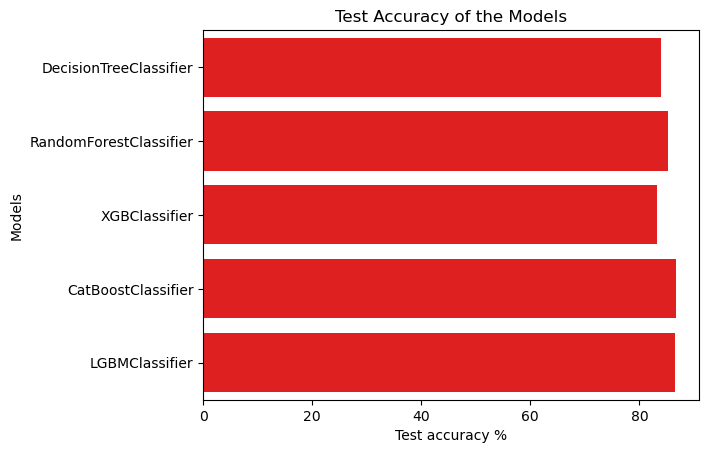

In [70]:
results = pd.DataFrame(columns=["Models", "Test accuracy"])
names = []
accs = []

for model in models:
    name = model.__class__.__name__
    names.append(name)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) 
    accs.append(acc)
    result = pd.DataFrame([[name, acc*100]], columns=["Models", "Test accuracy"])
    results = pd.concat([results, result])

sns.barplot(x="Test accuracy", y="Models", data=results, color="r")
plt.xlabel("Test accuracy %")
plt.title("Test Accuracy of the Models")
plt.show()

In [71]:
results.sort_values(by="Test accuracy", ascending=False, ignore_index=True)

,Models,Test accuracy
0,CatBoostClassifier,86.616667
1,LGBMClassifier,86.475000
2,RandomForestClassifier,85.208333
3,DecisionTreeClassifier,83.900000
4,XGBClassifier,83.233333


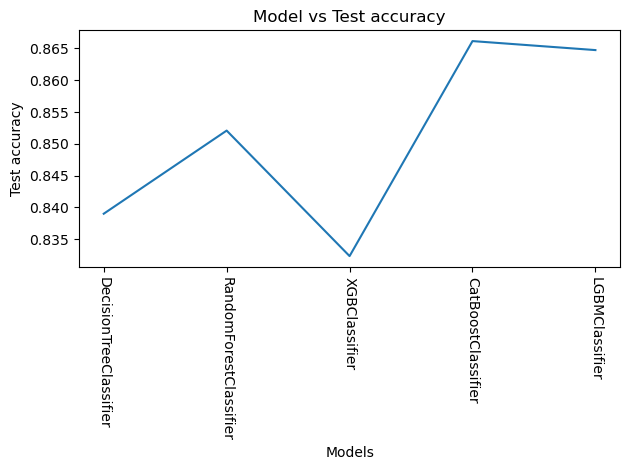

In [72]:
plt.plot(names, accs)
plt.xlabel("Models")
plt.ylabel("Test accuracy")
plt.title("Model vs Test accuracy")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()

**NOTE:**
- All models have high and similar/comparable accuracies.

## Modeling dropped

#### Justification for dropped features
- At this junction, we have completed our modeling process using all features but, before moving on to **Feature Importance**, we can explore a different avenue with regards to feature selection.
- Firstly, it should be noted that the `duration` and `campaign` features are deterministic in nature.
    - That is, while useful after collection, we can only know the length of the most recent call or the number of necessary calls after extensive and repetitive data collection.
    - Those features do not necessarily serve to give us demographical information about the customer segment(s) that would be willing or able to subscribe to a term deposit.
    - They are extrinsic in nature as opposed to the more intrinsic features such as a customer's `age`, `job`, `marital status`, `education level`, `debt level`, `bank balance`, `housing status`, and `loan status`.
    - Consequently, we will drop them and re-execute our initial analysis.
- Additionally, the `day`, `month` and `contact` features will be dropped for our secondary analysis as well.
    - The date of last contact may be immaterial if the business is not cyclical in nature and means of communication may be inconsequential as most people use cellphones regardless of demographic.
- We will perform our secondary analysis without these features **to see if the accuracy scores are comparable**.
    - Note that we fully expect the accuracy scores to reduce but if the decrease is not significant, it may provide some more intrinsic information about the customers or an avenue for further conversation with the client.

#### One hot encoding

In [73]:
df_enc_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4054 entries, 0 to 4053
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4054 non-null   int64
 1   job        4054 non-null   int64
 2   marital    4054 non-null   int64
 3   education  4054 non-null   int64
 4   default    4054 non-null   int64
 5   balance    4054 non-null   int64
 6   housing    4054 non-null   int64
 7   loan       4054 non-null   int64
 8   contact    4054 non-null   int64
 9   day        4054 non-null   int64
 10  month      4054 non-null   int64
 11  duration   4054 non-null   int64
 12  campaign   4054 non-null   int64
 13  y          4054 non-null   int64
dtypes: int64(14)
memory usage: 443.5 KB


In [74]:
print_uniques(df_enc_balanced)

age ------> [55 28 42 47 34 38 36 33 44 29 43 26 54 46 50 61 25 30 59 74 39 53 31 48
 41 45 32 35 49 37 40 27 52 95 57 56 51 62 58 73 24 23 60 65 71 69 77 21
 75 76 64 70 19 83 66 68 22 63 20 78 67 72 85 90]
job ------> [ 3  1  4  7  9  6 10  0  2  5  8]
marital ------> [1 2 0]
education ------> [0 1 2]
default ------> [0 1]
balance ------> [ 2152  2788  1628 ... -1944  2754  3655]
housing ------> [0 1]
loan ------> [0 1]
contact ------> [0 1]
day ------> [19  6 25 14 13 15 18  7 21 28  2  3 16 12 30 17 20  9 31 22 29 26  4  1
  5  8 24 27 23 11 10]
month ------> [ 6  5  8  0  9  3  7  1  4 10  2]
duration ------> [ 922  369  590 ... 1107 1231 2330]
campaign ------> [ 2  8  3  5  1  9  4 11  7 17 10  6 22 15 24 14 19 12 16 20 28 13 31 44
 32 39 25]
y ------> [1 0]


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [76]:
df_enc_balanced.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,55,3,1,0,0,2152,0,0,0,19,6,922,2,1
1,28,1,1,1,0,2788,1,0,0,6,6,369,2,1
2,42,1,2,0,0,1628,1,0,0,25,5,590,8,1
3,47,1,2,0,0,355,1,0,0,14,8,144,3,0
4,34,1,1,1,0,1089,1,0,0,13,8,394,3,1


In [77]:
# Drop the deterministic / less-intrinsic features from both the balanced
# training set and the held-out test set.
drop_cols = ["day", "month", "duration", "campaign", "contact"]
df_train_balanced_dropped = df_train_balanced.drop(drop_cols, axis=1)
df_test_enc_dropped = df_test_enc.drop(drop_cols, axis=1)

# Backwards-compatible alias used by descriptive cells in this section
df_enc_balanced_dropped = df_train_balanced_dropped


In [78]:
# One-hot encode the (column-dropped) training fold, then align test columns.
oh_cols = ["job", "marital", "education"]
df_train_oh_dropped = pd.get_dummies(df_train_balanced_dropped, columns=oh_cols, drop_first=True)
df_test_oh_dropped = pd.get_dummies(df_test_enc_dropped, columns=oh_cols, drop_first=True)
df_test_oh_dropped = df_test_oh_dropped.reindex(columns=df_train_oh_dropped.columns, fill_value=0)

# Backwards-compatible alias
df_enc_oh_dropped = df_train_oh_dropped
df_train_oh_dropped.head()


,age,default,balance,housing,loan,y,job_1,job_2,job_3,job_4,job_5,job_6,job_7,job_8,job_9,job_10,marital_1,marital_2,education_1,education_2
0,55,0,2152,0,0,1,False,False,True,False,False,False,False,False,False,False,True,False,False,False
1,28,0,2788,1,0,1,True,False,False,False,False,False,False,False,False,False,True,False,True,False
2,42,0,1628,1,0,1,True,False,False,False,False,False,False,False,False,False,False,True,False,False
3,47,0,355,1,0,0,True,False,False,False,False,False,False,False,False,False,False,True,False,False
4,34,0,1089,1,0,1,True,False,False,False,False,False,False,False,False,False,True,False,True,False


In [79]:
df_enc_oh_dropped.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'y', 'job_1', 'job_2',
       'job_3', 'job_4', 'job_5', 'job_6', 'job_7', 'job_8', 'job_9', 'job_10',
       'marital_1', 'marital_2', 'education_1', 'education_2'],
      dtype='object')

**NOTE:**
- We dropped the first columns to prevent issues with multi-collinearity.

#### Train and test split

In [80]:
X_train = df_train_oh_dropped.drop("y", axis=1)
y_train = df_train_oh_dropped["y"]
X_test = df_test_oh_dropped.drop("y", axis=1)
y_test = df_test_oh_dropped["y"]

print_bold("X_train.shape, y_train.shape, X_test.shape, y_test.shape:")
display(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print_bold("y_train.sum(), y_test.sum():")
display(y_train.sum(), y_test.sum())


X_train.shape, y_train.shape, X_test.shape, y_test.shape:


(4054, 19)

(4054,)

(12000, 19)

(12000,)

y_train.sum(), y_test.sum():


np.int64(2027)

np.int64(869)

#### Lazypredict

In [81]:
# Lazy preliminary assessment of multiple models
clf = LazyClassifier(verbose=-1, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models)

  0%|          | 0/33 [00:00<?, ?it/s]

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
BernoulliNB                    0.593750           0.593236  0.627706   
NearestCentroid                0.592000           0.591232  0.622157   
AdaBoostClassifier             0.593000           0.590710  0.637292   
RidgeClassifierCV              0.571000           0.589991  0.622133   
LogisticRegression             0.570917           0.589946  0.622223   
LinearDiscriminantAnalysis     0.570833           0.589901  0.622055   
RidgeClassifier                0.570833           0.589901  0.622058   
LinearSVC                      0.570833           0.589901  0.622057   
CalibratedClassifierCV         0.565833           0.588797  0.621920   
CatBoostClassifier             0.599417           0.587803  0.625250   
SVC                            0.567583           0.585497  0.619261   
QuadraticDiscriminantAnalysis  0.703000           0.582636  0.60

**NOTE:**
- Lazypredict provides an initial estimation of how different models may perform with the data.
- However, this assessment should be considered a rough guideline as it is made without model tuning.
- Thus, it will only serve informational purposes going forward.

#### Model evaluation functions

In [82]:
# Functions to evaluate models
def draw_roc(model):
    """ROC curve / AUC computed on the held-out test set only."""
    y_score = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "r--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - AUC (area={roc_auc:.4f})")
    plt.show()


def evaluate(model):
    """Fit, then report training/test accuracy, 5-fold CV (on TRAIN), report,
    ROC and confusion matrix."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cross_val = cross_val_score(model, X_train, y_train, cv=5).mean()
    print_bold(f"Training accuracy: {model.score(X_train, y_train)}")
    print_bold(f"Test accuracy: {accuracy_score(y_test, y_pred)}")
    print_bold(f"5-Fold Cross Validation Accuracy: {cross_val}")
    barrier()
    print_bold("Classification report:")
    print(classification_report(y_test, y_pred))
    barrier()
    draw_roc(model)
    barrier()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title("Confusion Matrix")
    plt.show()


def evaluate_no_fit(model):
    """Same as ``evaluate`` but assumes the model has already been fit."""
    y_pred = model.predict(X_test)
    cross_val = cross_val_score(model, X_train, y_train, cv=5).mean()
    print_bold(f"Training accuracy: {model.score(X_train, y_train)}")
    print_bold(f"Test accuracy: {accuracy_score(y_test, y_pred)}")
    print_bold(f"5-Fold Cross Validation Accuracy: {cross_val}")
    barrier()
    print_bold("Classification report:")
    print(classification_report(y_test, y_pred))
    barrier()
    draw_roc(model)
    barrier()
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title("Confusion Matrix")
    plt.show()


def cv_std(cv):
    """Plot the std-dev of CV scores across the GridSearchCV parameter grid."""
    y_std = cv.cv_results_["std_test_score"]
    x = np.arange(1, y_std.shape[0] + 1)
    print(f"Mean of the standard deviations: {y_std.mean()}")
    print(f"Std of the standard deviations: {y_std.std()}")
    barrier()
    plt.plot(x, y_std)
    plt.title("Standard devs of CV scores")
    plt.xlabel("Param Candidates")
    plt.ylabel("Stds")
    plt.show()


### Logistic regression

Training accuracy: 0.5799210656142082
Test accuracy: 0.568
5-Fold Cross Validation Accuracy: 0.565609291988248

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.57      0.71     11131
           1       0.10      0.60      0.17       869

    accuracy                           0.57     12000
   macro avg       0.52      0.58      0.44     12000
weighted avg       0.89      0.57      0.67     12000


 <<< -------------------------------------------------- >>> 



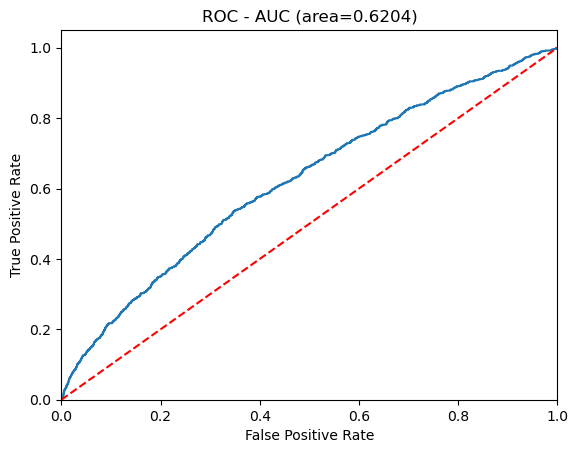


 <<< -------------------------------------------------- >>> 



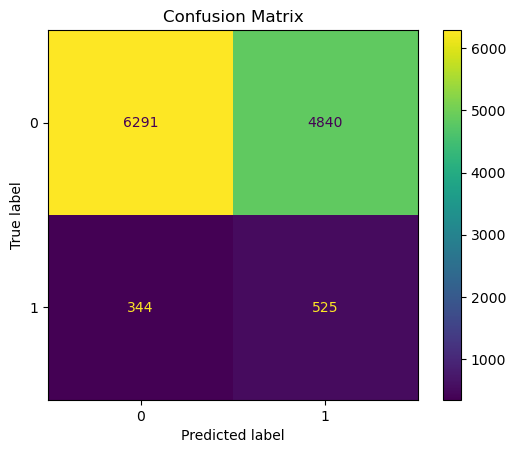

In [83]:
LR = LogisticRegression()
evaluate(LR)

In [84]:
# Save model
save_model_dropped(LR, "LR")


Model: LR.pkl saved to models_dropped/.


### Gaussian naive bayes

Training accuracy: 0.5614208189442526
Test accuracy: 0.6685833333333333
5-Fold Cross Validation Accuracy: 0.5535263582530332

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     11131
           1       0.11      0.48      0.17       869

    accuracy                           0.67     12000
   macro avg       0.52      0.58      0.48     12000
weighted avg       0.88      0.67      0.75     12000


 <<< -------------------------------------------------- >>> 



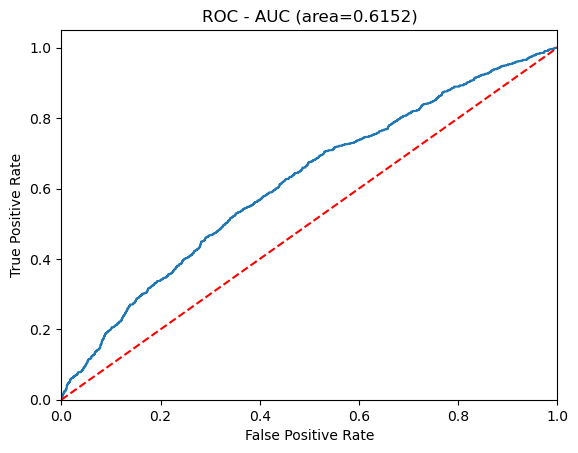


 <<< -------------------------------------------------- >>> 



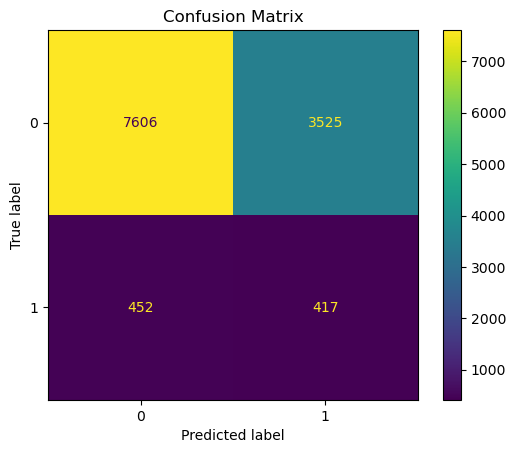

In [85]:
GNB = GaussianNB()
evaluate(GNB)

In [86]:
# Save model
save_model_dropped(GNB, "GNB")


Model: GNB.pkl saved to models_dropped/.


### K nearest neighbours

Training accuracy: 0.7017760236803158
Test accuracy: 0.5384166666666667
5-Fold Cross Validation Accuracy: 0.5350215402414334

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.54      0.68     11131
           1       0.08      0.51      0.14       869

    accuracy                           0.54     12000
   macro avg       0.51      0.53      0.41     12000
weighted avg       0.87      0.54      0.65     12000


 <<< -------------------------------------------------- >>> 



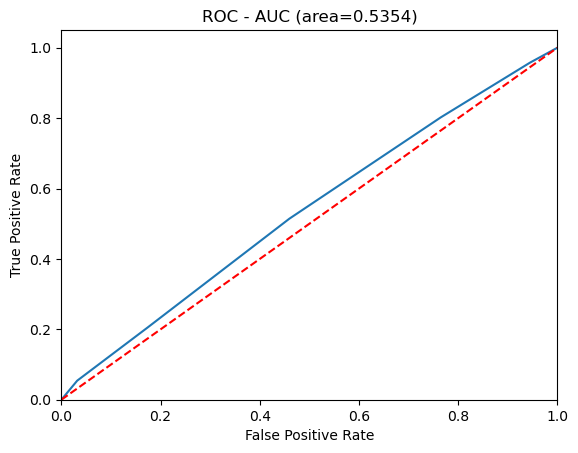


 <<< -------------------------------------------------- >>> 



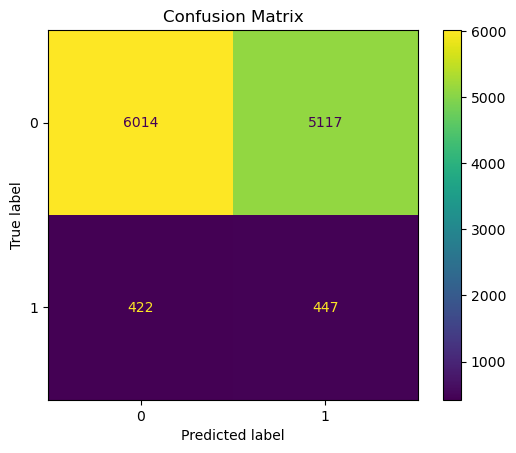

In [87]:
KNN = KNeighborsClassifier()
evaluate(KNN)

Fitting 5 folds for each of 14 candidates, totalling 70 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'n_neighbors': np.int64(3)}
Tuned model best score: 0.5446420361997838
Training accuracy: 0.7686235816477553
Test accuracy: 0.5386666666666666
5-Fold Cross Validation Accuracy: 0.5446420361997838

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.54      0.69     11131
           1       0.08      0.51      0.14       869

    accuracy                           0.54     12000
   macro avg       0.51      0.52      0.41     12000
weighted avg       0.87      0.54      0.65     12000


 <<< -------------------------------------------------- >>> 



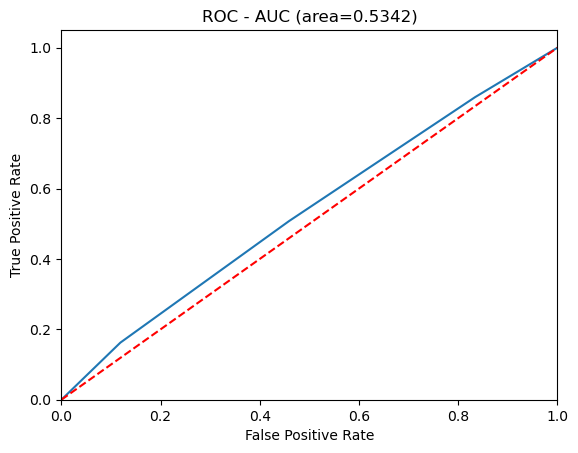


 <<< -------------------------------------------------- >>> 



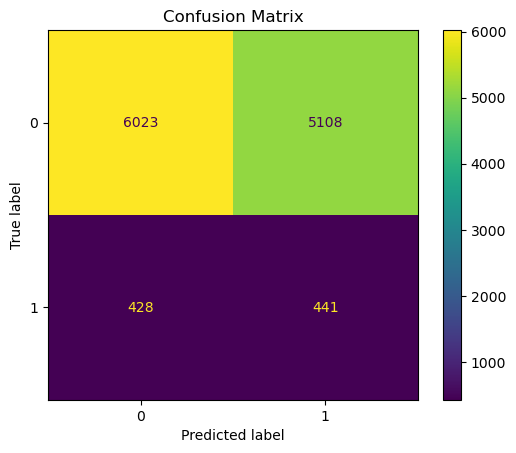

In [88]:
KNN = KNeighborsClassifier()

param_grid = {"n_neighbors": np.arange(1, 15)}

model_cv = GridSearchCV(KNN, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.7686235816477553
Test accuracy: 0.5386666666666666
5-Fold Cross Validation Accuracy: 0.5446420361997838

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.54      0.69     11131
           1       0.08      0.51      0.14       869

    accuracy                           0.54     12000
   macro avg       0.51      0.52      0.41     12000
weighted avg       0.87      0.54      0.65     12000


 <<< -------------------------------------------------- >>> 



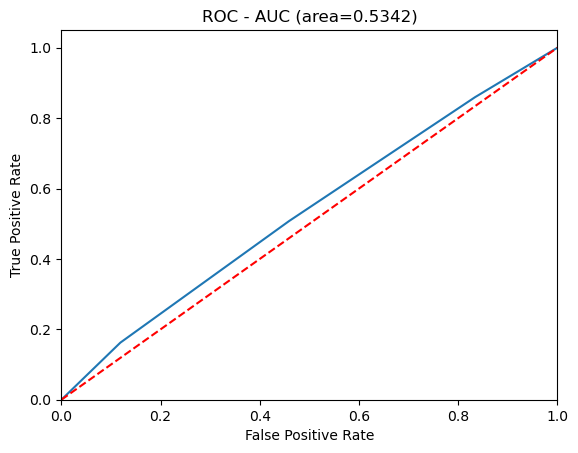


 <<< -------------------------------------------------- >>> 



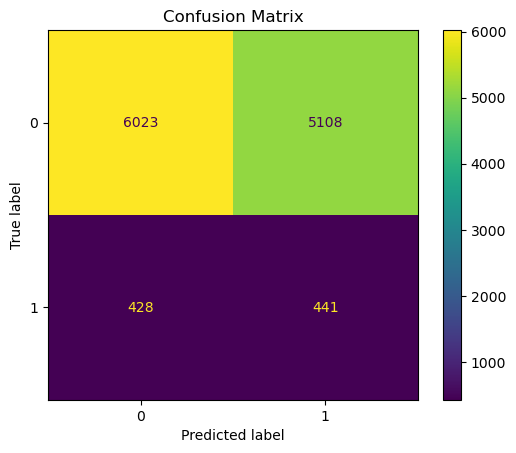

In [89]:
KNN = KNeighborsClassifier().set_params(**model_cv.best_params_)
evaluate(KNN)

### Decision tree

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'max_depth': 5, 'min_samples_split': 43}
Tuned model best score: 0.5636403769161682
Training accuracy: 0.5944745929945733
Test accuracy: 0.5030833333333333
5-Fold Cross Validation Accuracy: 0.5636403769161682

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.49      0.65     11131
           1       0.09      0.65      0.16       869

    accuracy                           0.50     12000
   macro avg       0.52      0.57      0.40     12000
weighted avg       0.89      0.50      0.61     12000


 <<< -------------------------------------------------- >>> 



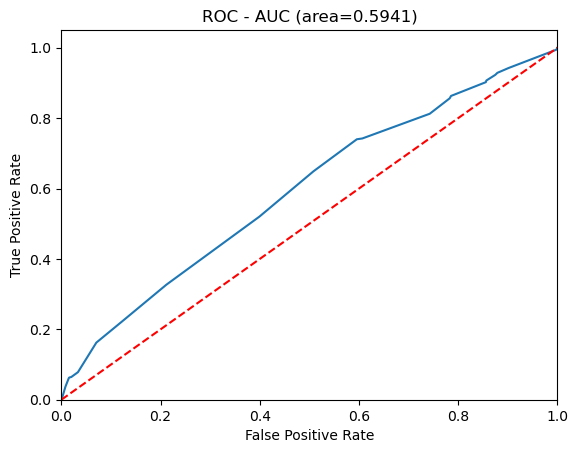


 <<< -------------------------------------------------- >>> 



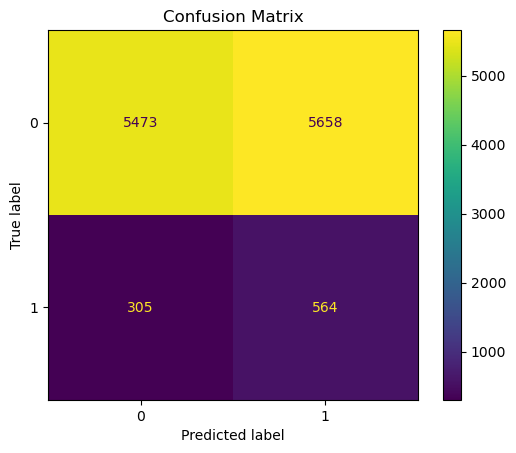

In [90]:
DTC = DecisionTreeClassifier()

param_grid = {"max_depth": range(1, 10), "min_samples_split": list(range(2, 50))}

model_cv = GridSearchCV(DTC, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.5944745929945733
Test accuracy: 0.5030833333333333
5-Fold Cross Validation Accuracy: 0.5636403769161682

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.49      0.65     11131
           1       0.09      0.65      0.16       869

    accuracy                           0.50     12000
   macro avg       0.52      0.57      0.40     12000
weighted avg       0.89      0.50      0.61     12000


 <<< -------------------------------------------------- >>> 



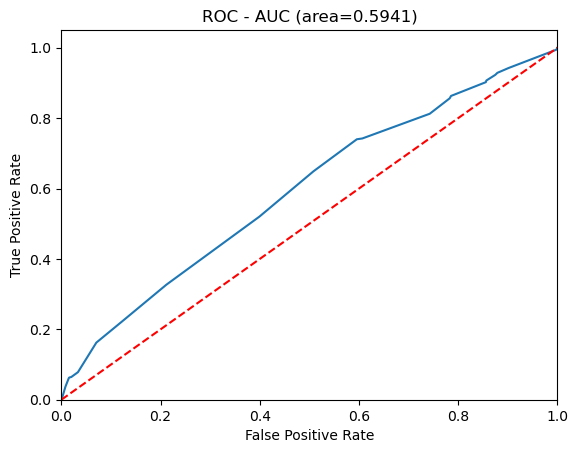


 <<< -------------------------------------------------- >>> 



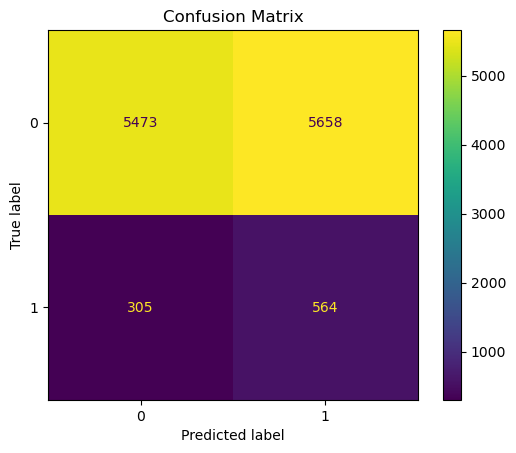

In [91]:
DTC = DecisionTreeClassifier().set_params(**model_cv.best_params_)
evaluate(DTC)

In [92]:
# Save model
save_model_dropped(DTC, "DTC")

Model: DTC.pkl saved to models_dropped/.


### Random forest

Fitting 5 folds for each of 81 candidates, totalling 405 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'max_depth': 5, 'max_features': 5, 'min_samples_split': 10, 'n_estimators': 50}
Tuned model best score: 0.5823802347353519
Training accuracy: 0.6132215096201282
Test accuracy: 0.6230833333333333
5-Fold Cross Validation Accuracy: 0.5742430469927386

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.63      0.76     11131
           1       0.11      0.56      0.18       869

    accuracy                           0.62     12000
   macro avg       0.53      0.59      0.47     12000
weighted avg       0.89      0.62      0.71     12000


 <<< -------------------------------------------------- >>> 



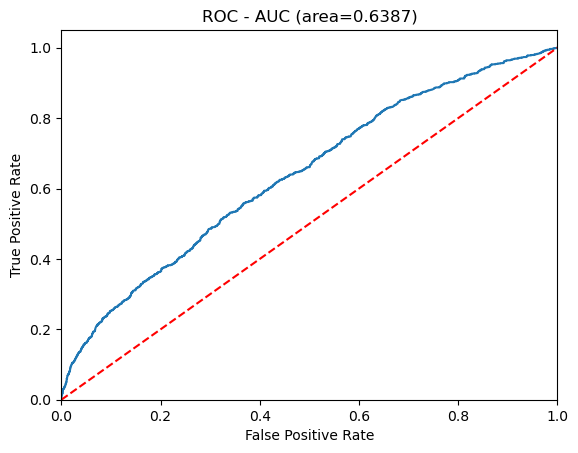


 <<< -------------------------------------------------- >>> 



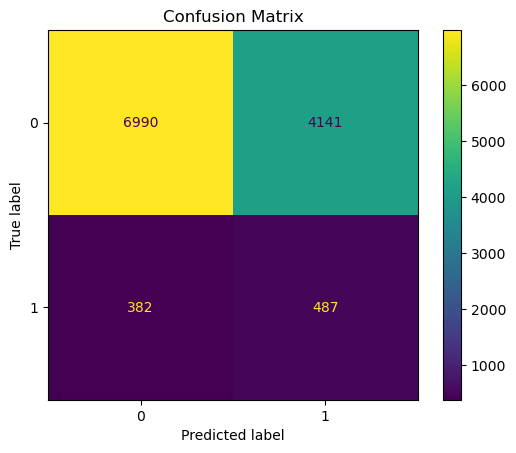

In [93]:
RF = RandomForestClassifier()

param_grid = {"max_depth":[2,5,8], "max_features":[2,5,8], "n_estimators":[10,50,100], "min_samples_split":[2,5,10]}

model_cv = GridSearchCV(RF, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.6191415885545141
Test accuracy: 0.61275
5-Fold Cross Validation Accuracy: 0.5727615655112573

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     11131
           1       0.10      0.56      0.17       869

    accuracy                           0.61     12000
   macro avg       0.52      0.59      0.46     12000
weighted avg       0.89      0.61      0.71     12000


 <<< -------------------------------------------------- >>> 



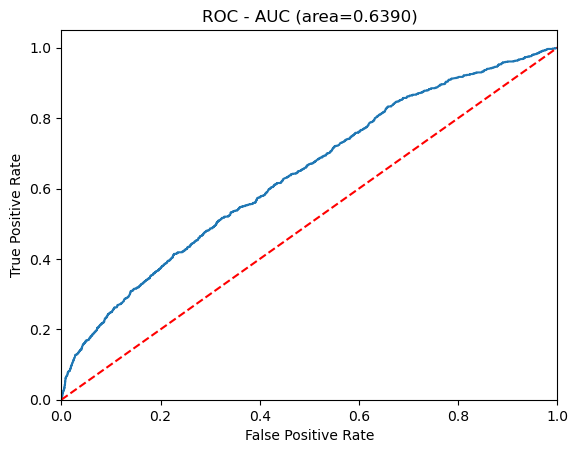


 <<< -------------------------------------------------- >>> 



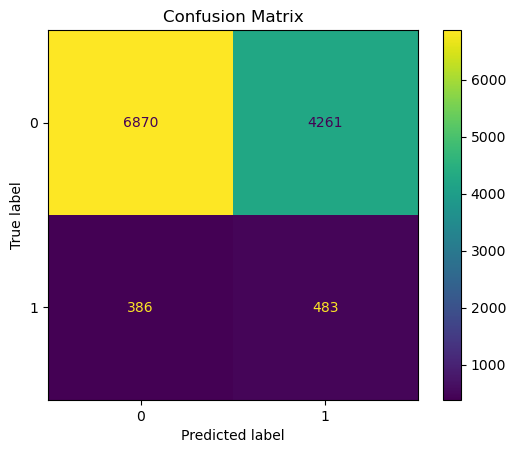

In [94]:
RF = RandomForestClassifier().set_params(**model_cv.best_params_)
evaluate(RF)

In [95]:
# Save model
save_model_dropped(RF, "RF")

Model: RF.pkl saved to models_dropped/.


### XGBoost

Training accuracy: 0.6593487913172176
Test accuracy: 0.6005833333333334
5-Fold Cross Validation Accuracy: 0.5702954742658812

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.60      0.74     11131
           1       0.10      0.58      0.17       869

    accuracy                           0.60     12000
   macro avg       0.52      0.59      0.45     12000
weighted avg       0.89      0.60      0.70     12000


 <<< -------------------------------------------------- >>> 



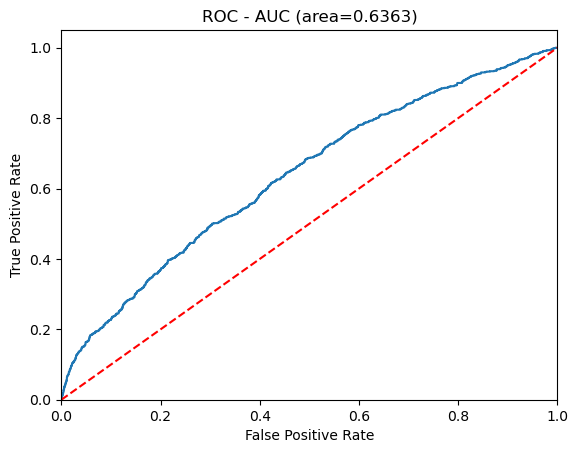


 <<< -------------------------------------------------- >>> 



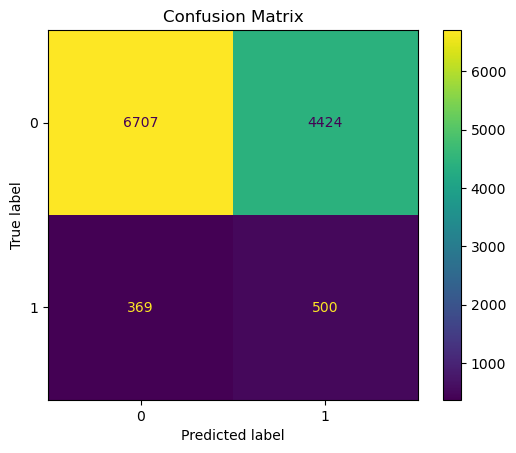

In [96]:
XGB = XGBClassifier(learning_rate=0.01, max_depth=6, min_samples_split=2, n_estimators=100, subsample=0.8)
evaluate(XGB)

In [97]:
# Save model
save_model_dropped(XGB, "XGB")

Model: XGB.pkl saved to models_dropped/.


### CatBoost

Training accuracy: 0.730389738529847
Test accuracy: 0.5994166666666667
5-Fold Cross Validation Accuracy: 0.5633928544245026

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.60      0.74     11131
           1       0.10      0.57      0.17       869

    accuracy                           0.60     12000
   macro avg       0.52      0.59      0.45     12000
weighted avg       0.89      0.60      0.69     12000


 <<< -------------------------------------------------- >>> 



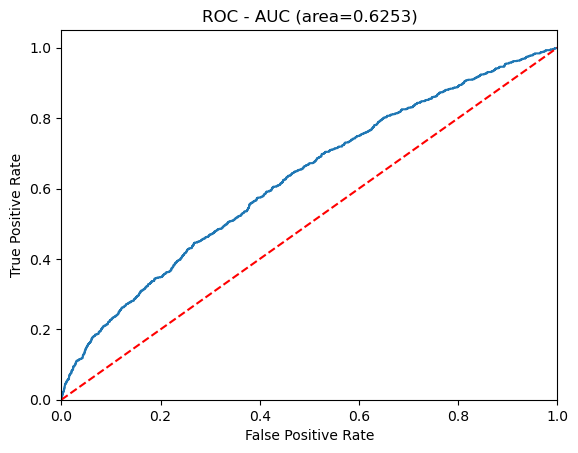


 <<< -------------------------------------------------- >>> 



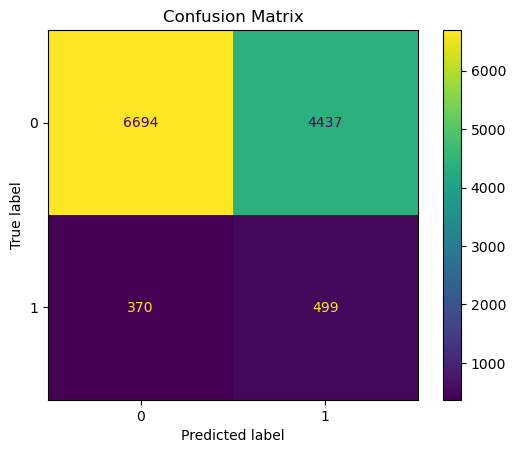

In [98]:
CAT = CatBoostClassifier(verbose=False)
# CAT = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5, verbose=False)
evaluate(CAT)

In [99]:
# Save model
save_model_dropped(CAT, "CAT")

Model: CAT.pkl saved to models_dropped/.


### LGBMClassifier

Training accuracy: 0.7742969906265417
Test accuracy: 0.5740833333333333
5-Fold Cross Validation Accuracy: 0.546370126805803

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.57      0.71     11131
           1       0.10      0.58      0.17       869

    accuracy                           0.57     12000
   macro avg       0.52      0.58      0.44     12000
weighted avg       0.88      0.57      0.67     12000


 <<< -------------------------------------------------- >>> 



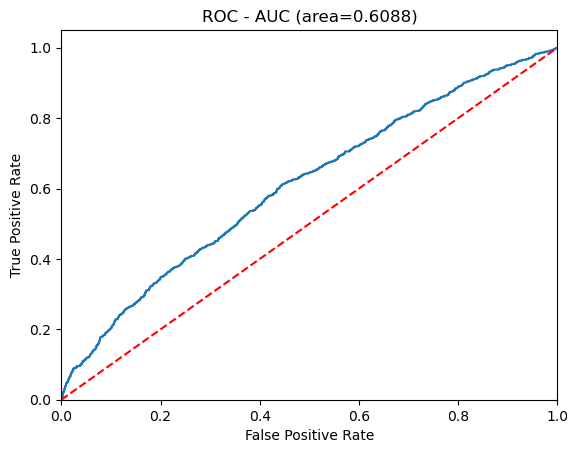


 <<< -------------------------------------------------- >>> 



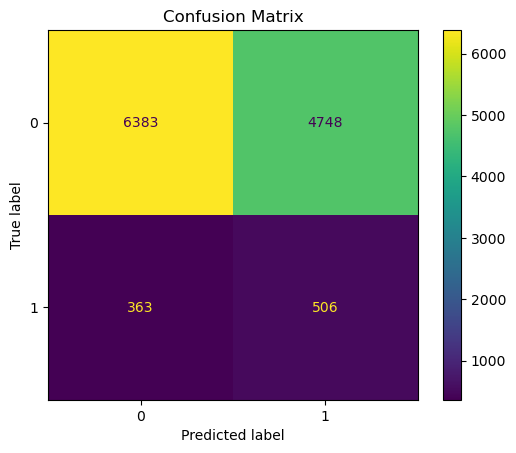

In [100]:
LGBM = LGBMClassifier(verbosity=-1)
evaluate(LGBM)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

 <<< -------------------------------------------------- >>> 

Tuned model parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_samples': 20, 'n_estimators': 500, 'subsample': 0.6}
Tuned model best score: 0.5789304470932092
Training accuracy: 0.6171682289097188
Test accuracy: 0.6006666666666667
5-Fold Cross Validation Accuracy: 0.5789304470932092

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.60      0.74     11131
           1       0.10      0.59      0.18       869

    accuracy                           0.60     12000
   macro avg       0.53      0.60      0.46     12000
weighted avg       0.89      0.60      0.70     12000


 <<< -------------------------------------------------- >>> 



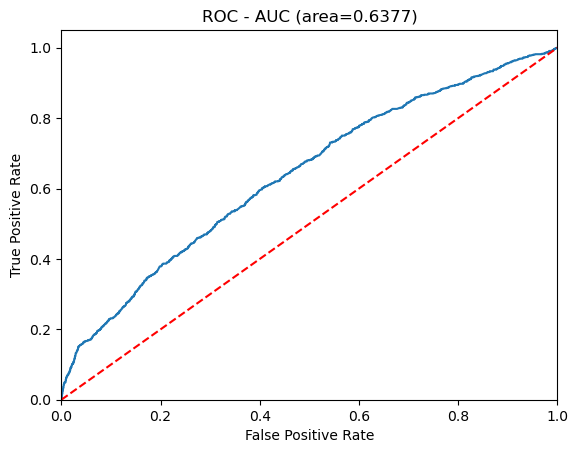


 <<< -------------------------------------------------- >>> 



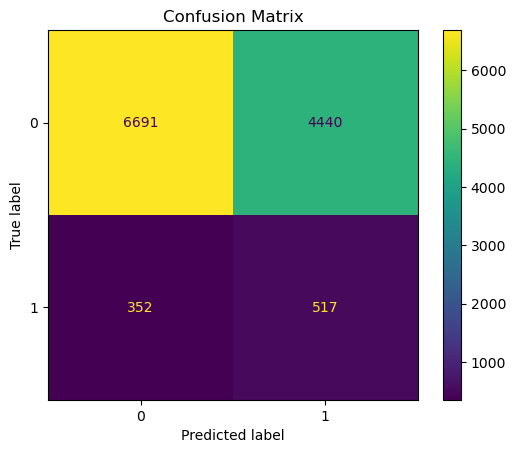

In [101]:
LGBM = LGBMClassifier(verbosity=-1)

param_grid = {"n_estimators":[100, 500], "subsample":[0.6,0.8,1.0], "max_depth":[3, 4, 5],
              "learning_rate":[0.1, 0.01, 0.05], "min_child_samples":[5, 10, 20]}

model_cv = GridSearchCV(LGBM, param_grid, cv=5, n_jobs=-1, verbose=1)
model_cv.fit(X_train, y_train)
barrier()
print(f"Tuned model parameters: {model_cv.best_params_}")
print(f"Tuned model best score: {model_cv.best_score_}")
evaluate_no_fit(model_cv.best_estimator_)

Training accuracy: 0.6171682289097188
Test accuracy: 0.6006666666666667
5-Fold Cross Validation Accuracy: 0.5789304470932092

 <<< -------------------------------------------------- >>> 

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.60      0.74     11131
           1       0.10      0.59      0.18       869

    accuracy                           0.60     12000
   macro avg       0.53      0.60      0.46     12000
weighted avg       0.89      0.60      0.70     12000


 <<< -------------------------------------------------- >>> 



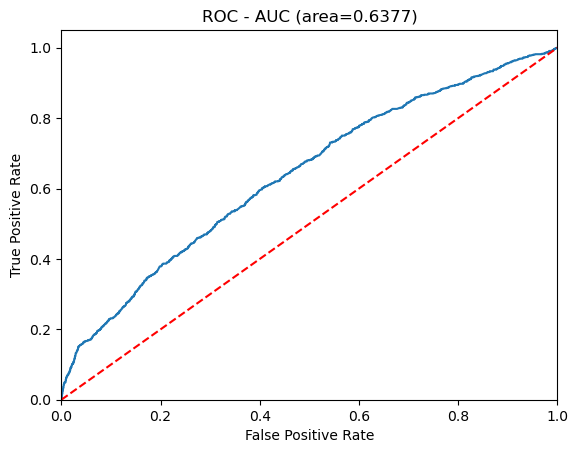


 <<< -------------------------------------------------- >>> 



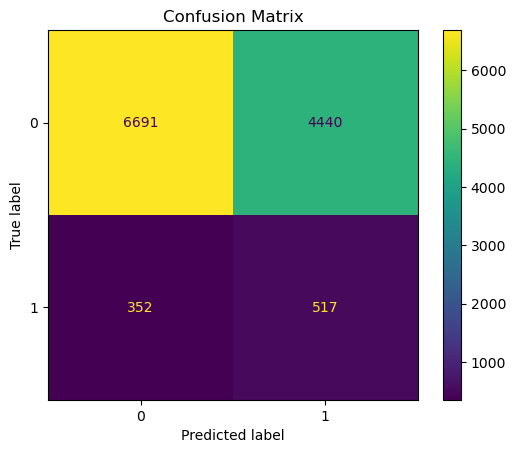

In [102]:
LGBM = LGBMClassifier(verbosity=-1).set_params(**model_cv.best_params_)
evaluate(LGBM)

In [103]:
# Save model
save_model_dropped(LGBM, "LGBM")

Model: LGBM.pkl saved to models_dropped/.


### Final model collation

In [104]:
# Load saved models
DTC_feat_imp = load_model_dropped("DTC.pkl")
RF_feat_imp = load_model_dropped("RF.pkl")
XGB_feat_imp = load_model_dropped("XGB.pkl")
CAT_feat_imp = load_model_dropped("CAT.pkl")
LGBM_feat_imp = load_model_dropped("LGBM.pkl")

In [105]:
models = [DTC_feat_imp, RF_feat_imp, XGB_feat_imp, CAT_feat_imp, LGBM_feat_imp]

for model in models:
    names = model.__class__.__name__
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print_bold(names + ":" )
    print(f"Test accuracy: {acc}")
    barrier()

DecisionTreeClassifier:
Test accuracy: 0.5030833333333333

 <<< -------------------------------------------------- >>> 

RandomForestClassifier:
Test accuracy: 0.61275

 <<< -------------------------------------------------- >>> 

XGBClassifier:
Test accuracy: 0.6005833333333334

 <<< -------------------------------------------------- >>> 

CatBoostClassifier:
Test accuracy: 0.5994166666666667

 <<< -------------------------------------------------- >>> 

LGBMClassifier:
Test accuracy: 0.6006666666666667

 <<< -------------------------------------------------- >>> 



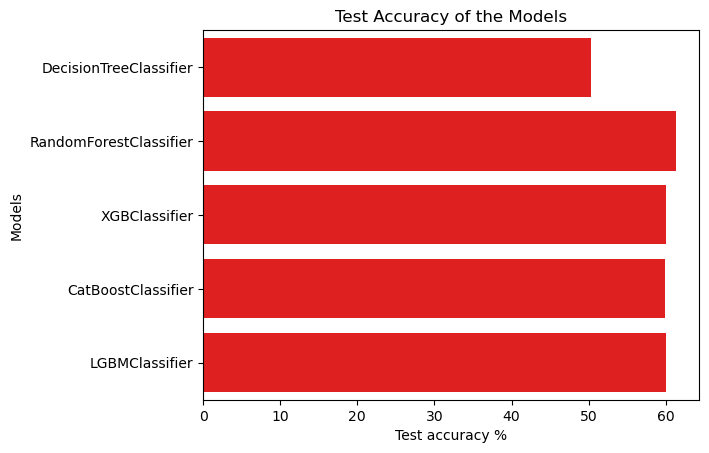

In [106]:
results = pd.DataFrame(columns=["Models", "Test accuracy"])
names = []
accs = []

for model in models:
    name = model.__class__.__name__
    names.append(name)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) 
    accs.append(acc)
    result = pd.DataFrame([[name, acc*100]], columns=["Models", "Test accuracy"])
    results = pd.concat([results, result])

sns.barplot(x="Test accuracy", y="Models", data=results, color="r")
plt.xlabel("Test accuracy %")
plt.title("Test Accuracy of the Models")
plt.show()

In [107]:
results.sort_values(by="Test accuracy", ascending=False, ignore_index=True)

,Models,Test accuracy
0,RandomForestClassifier,61.275000
1,LGBMClassifier,60.066667
2,XGBClassifier,60.058333
3,CatBoostClassifier,59.941667
4,DecisionTreeClassifier,50.308333


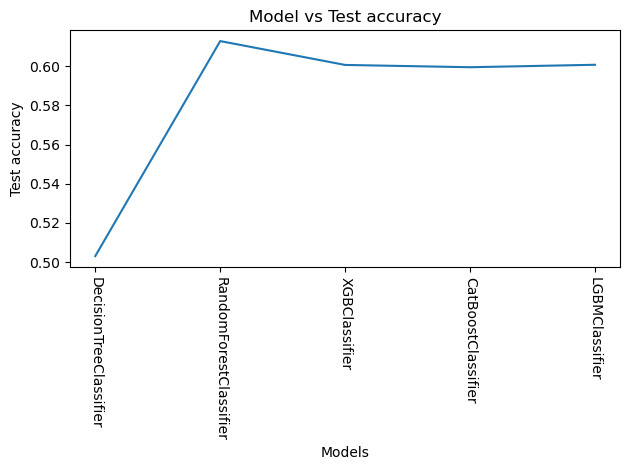

In [108]:
plt.plot(names, accs)
plt.xlabel("Models")
plt.ylabel("Test accuracy")
plt.title("Model vs Test accuracy")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()

**NOTE:**
- All accuracies drop to just above 50% suggesting that they are slightly better than random guessing.
- For now, we will incorporate all features into our analysis and ignore this secondary analysis.

## Final conclusion & Inference

**Scope:**
- ACME is a company that provides machine learning solutions in the European banking market. They are interested in developing a machine learning system that can improve the success rate for calls made to customers for any product that their clients offer.

**Our goal:**
- Predict if the customer will subscribe (yes/no) to a term deposit (variable y).
- Hit 81% or above accuracy by evaluating with 5-fold cross validation and reporting the average performance score.

**Data Wrangling:**
- The data was provided by the client and contained the following features: *age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, y/output*.

**Exploratory Data Analysis, Preprocessing and Training:**
- The data was *plotted* for visualization and *cleaned* of all missing values using *random imputation*.
- The data was *label encoded* and *one-hot encoded* for better modeling.
- The target feature was also balanced using random sampling so that both classes of output (yes or no) were equally represented.
- The data was split into training and test sets for evaluation and to evaluate any potential over-fitting.

**Modeling:**
- Multiple models were trained and evaluated using the training and test sets.
- Evaluation included the generation of *training accuracy, test accuracy, 5-fold cross validation accuracy, roc curve, roc-auc, precision, recall and f1-score*.
- CatBoostClassifier, LGBMClassifier, RandomForestClassifier, XGBClassifier and DecisionTreeClassifier all surpassed the goal of 81% test accuracy with `CatBoostClassifier` and `RandomForestClassifier` producing the best results of **~87%** test accuracy each.
- Secondary analysis using a sub-set of the data was shown to be almost no better than random guessing and will be ignored going forward.

**See notebook_2 for:**
- Feature importance
- Customer segmentation